# pyCisTopic scATAC processing

In [1]:
import pycisTopic
import pandas as pd
import os
pycisTopic.__version__

'2.0a0'

In [4]:
os.chdir(os.getcwd())

### Once the cistopic modeling is finished

In [ ]:
! cat logs/R-cistopic_modelling.*.out

In [7]:
import pickle
file_path = os.path.join(os.getcwd(), "outs/cistopic_obj.pkl")
with open(file_path, 'rb') as file:
    cistopic_obj = pickle.load(file)

print(cistopic_obj)

CistopicObject from project cisTopic_merge with n_cells × n_regions = 2108 × 179331


In [8]:
cistopic_obj.cell_data

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,barcode_rank,total_fragments_count,log10_total_fragments_count,unique_fragments_count,log10_unique_fragments_count,...,duplication_ratio,tss_enrichment,pdf_values_for_tss_enrichment,pdf_values_for_fraction_of_fragments_in_peaks,pdf_values_for_duplication_ratio,barcode,doublets_atac,doublet_outlier,cell_type,sample
ACGCAAGCAGGAATCG-1-Q3___Q3,20049,4.302093,14510,4.161667,Q3,190,55419,4.743667,30767,4.488099,...,0.444829,24.637034,0.001652,0.081951,0.508806,ACGCAAGCAGGAATCG-1,False,False,Tem_Trm_cytotoxic_T_cells,Q3
AACTACTCAAGTCGCT-1-Q3___Q3,6785,3.83155,5660,3.752816,Q3,692,18389,4.264582,10676,4.028449,...,0.419436,24.862052,0.005086,0.186507,0.551537,AACTACTCAAGTCGCT-1,False,False,Tcm_Naive_helper_T_cells,Q3
AGCCAGTGTCATAACG-1-Q3___Q3,9067,3.957464,7922,3.898835,Q3,403,29614,4.471512,16228,4.210292,...,0.452016,17.980282,0.001964,0.050032,1.121027,AGCCAGTGTCATAACG-1,False,False,Classical_monocytes,Q3
AGACAATAGTAACCAC-1-Q3___Q3,2602,3.415307,2403,3.380754,Q3,1455,7644,3.883377,4261,3.629613,...,0.442569,26.104412,0.004721,0.116732,1.773470,AGACAATAGTAACCAC-1,False,False,Pro-B_cells_Q3,Q3
CGATGTCCACGTAATT-1-Q3___Q3,13796,4.139753,11665,4.066885,Q3,215,48331,4.684235,27219,4.434888,...,0.436821,16.708066,0.000945,0.023678,0.755477,CGATGTCCACGTAATT-1,False,False,Pro-B_cells_Q3,Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TATAGCTCATTGCGAC-1-Q3___Q3,1931,3.285782,1811,3.257918,Q3,1936,4791,3.680517,2560,3.408410,...,0.465665,27.570784,0.003481,0.389275,0.518058,TATAGCTCATTGCGAC-1,False,False,Pro-B_cells_Q3,Q3
AAACGCGCAACAACAA-1-Q3___Q3,1081,3.033826,1001,3.000434,Q3,2324,2622,3.418798,1519,3.181844,...,0.420671,39.313674,0.000137,0.304121,0.554992,AAACGCGCAACAACAA-1,False,False,Classical_monocytes,Q3
CGAGGAAGTGTGAGAG-1-Q3___Q3,1476,3.169086,1377,3.138934,Q3,2156,3512,3.545678,1936,3.287130,...,0.448747,29.517257,0.002577,0.280806,1.202149,CGAGGAAGTGTGAGAG-1,False,False,Tem_Trm_cytotoxic_T_cells,Q3
AGCCGGTTCGTTACTT-1-Q3___Q3,1291,3.110926,1259,3.100026,Q3,2085,3874,3.588272,2121,3.326745,...,0.452504,25.182607,0.003094,0.072250,0.954257,AGCCGGTTCGTTACTT-1,False,False,Pro-B_cells_Q3,Q3


In [9]:
file_path = os.path.join(os.getcwd(), "outs/models.pkl")

with open(file_path, 'rb') as file:
    models = pickle.load(file)

print(models)

/opt/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-11 14:01:20,563	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


[<pycisTopic.lda_models.CistopicLDAModel object at 0x15189a3bc6d0>, <pycisTopic.lda_models.CistopicLDAModel object at 0x15186ba81450>, <pycisTopic.lda_models.CistopicLDAModel object at 0x15186ab88490>, <pycisTopic.lda_models.CistopicLDAModel object at 0x15186ab8b690>, <pycisTopic.lda_models.CistopicLDAModel object at 0x15186ab9ac90>]


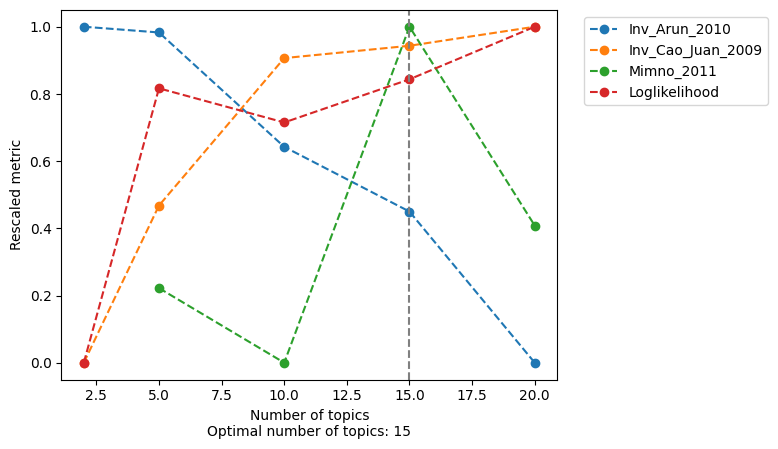

In [10]:
from pycisTopic.lda_models import evaluate_models
model = evaluate_models(
    models,
    select_model = 15,
    return_model = True
)

choosing model with 15 topics

In [11]:
cistopic_obj.add_LDA_model(model)

In [12]:
out_dir = "outs"
os.makedirs(out_dir, exist_ok = True)

In [13]:
pickle.dump(
    cistopic_obj,
    open(os.path.join(out_dir, "cistopic_obj.pkl"), "wb")
)

# Clustering and visualisation

In [14]:
from pycisTopic.clust_vis import (
    find_clusters,
    run_umap,
    run_tsne,
    plot_metadata,
    plot_topic,
    cell_topic_heatmap
)

In [15]:
find_clusters(
    cistopic_obj,
    target  = 'cell',
    k = 10,
    res = [0.2,0.3,0.6, 1.2, 3,6],
    prefix = 'pycisTopic_',
    scale = True,
    split_pattern = '-'
)

2025-07-11 14:01:51,052 cisTopic     INFO     Finding neighbours


In [16]:
cistopic_obj.cell_data

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,barcode_rank,total_fragments_count,log10_total_fragments_count,unique_fragments_count,log10_unique_fragments_count,...,doublets_atac,doublet_outlier,cell_type,sample,pycisTopic_leiden_10_0.2,pycisTopic_leiden_10_0.3,pycisTopic_leiden_10_0.6,pycisTopic_leiden_10_1.2,pycisTopic_leiden_10_3,pycisTopic_leiden_10_6
ACGCAAGCAGGAATCG-1-Q3___Q3,20049,4.302093,14510,4.161667,Q3,190,55419,4.743667,30767,4.488099,...,False,False,Tem_Trm_cytotoxic_T_cells,Q3,4,3,5,13,11,15
AACTACTCAAGTCGCT-1-Q3___Q3,6785,3.83155,5660,3.752816,Q3,692,18389,4.264582,10676,4.028449,...,False,False,Tcm_Naive_helper_T_cells,Q3,3,4,6,9,1,39
AGCCAGTGTCATAACG-1-Q3___Q3,9067,3.957464,7922,3.898835,Q3,403,29614,4.471512,16228,4.210292,...,False,False,Classical_monocytes,Q3,5,5,9,14,8,55
AGACAATAGTAACCAC-1-Q3___Q3,2602,3.415307,2403,3.380754,Q3,1455,7644,3.883377,4261,3.629613,...,False,False,Pro-B_cells_Q3,Q3,3,3,10,17,28,20
CGATGTCCACGTAATT-1-Q3___Q3,13796,4.139753,11665,4.066885,Q3,215,48331,4.684235,27219,4.434888,...,False,False,Pro-B_cells_Q3,Q3,0,0,3,3,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TATAGCTCATTGCGAC-1-Q3___Q3,1931,3.285782,1811,3.257918,Q3,1936,4791,3.680517,2560,3.408410,...,False,False,Pro-B_cells_Q3,Q3,0,0,2,6,10,5
AAACGCGCAACAACAA-1-Q3___Q3,1081,3.033826,1001,3.000434,Q3,2324,2622,3.418798,1519,3.181844,...,False,False,Classical_monocytes,Q3,5,5,9,14,8,50
CGAGGAAGTGTGAGAG-1-Q3___Q3,1476,3.169086,1377,3.138934,Q3,2156,3512,3.545678,1936,3.287130,...,False,False,Tem_Trm_cytotoxic_T_cells,Q3,2,2,1,10,26,32
AGCCGGTTCGTTACTT-1-Q3___Q3,1291,3.110926,1259,3.100026,Q3,2085,3874,3.588272,2121,3.326745,...,False,False,Pro-B_cells_Q3,Q3,0,0,2,1,15,33


In [18]:
cistopic_obj.projections["cell"] = {}
run_umap(
    cistopic_obj,
    target  = 'cell', scale=True)

2025-07-11 14:02:41,725 cisTopic     INFO     Running UMAP


/opt/venv/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [19]:
run_tsne(
    cistopic_obj,
    target  = 'cell', scale=True)

2025-07-11 14:02:47,683 cisTopic     INFO     Running TSNE


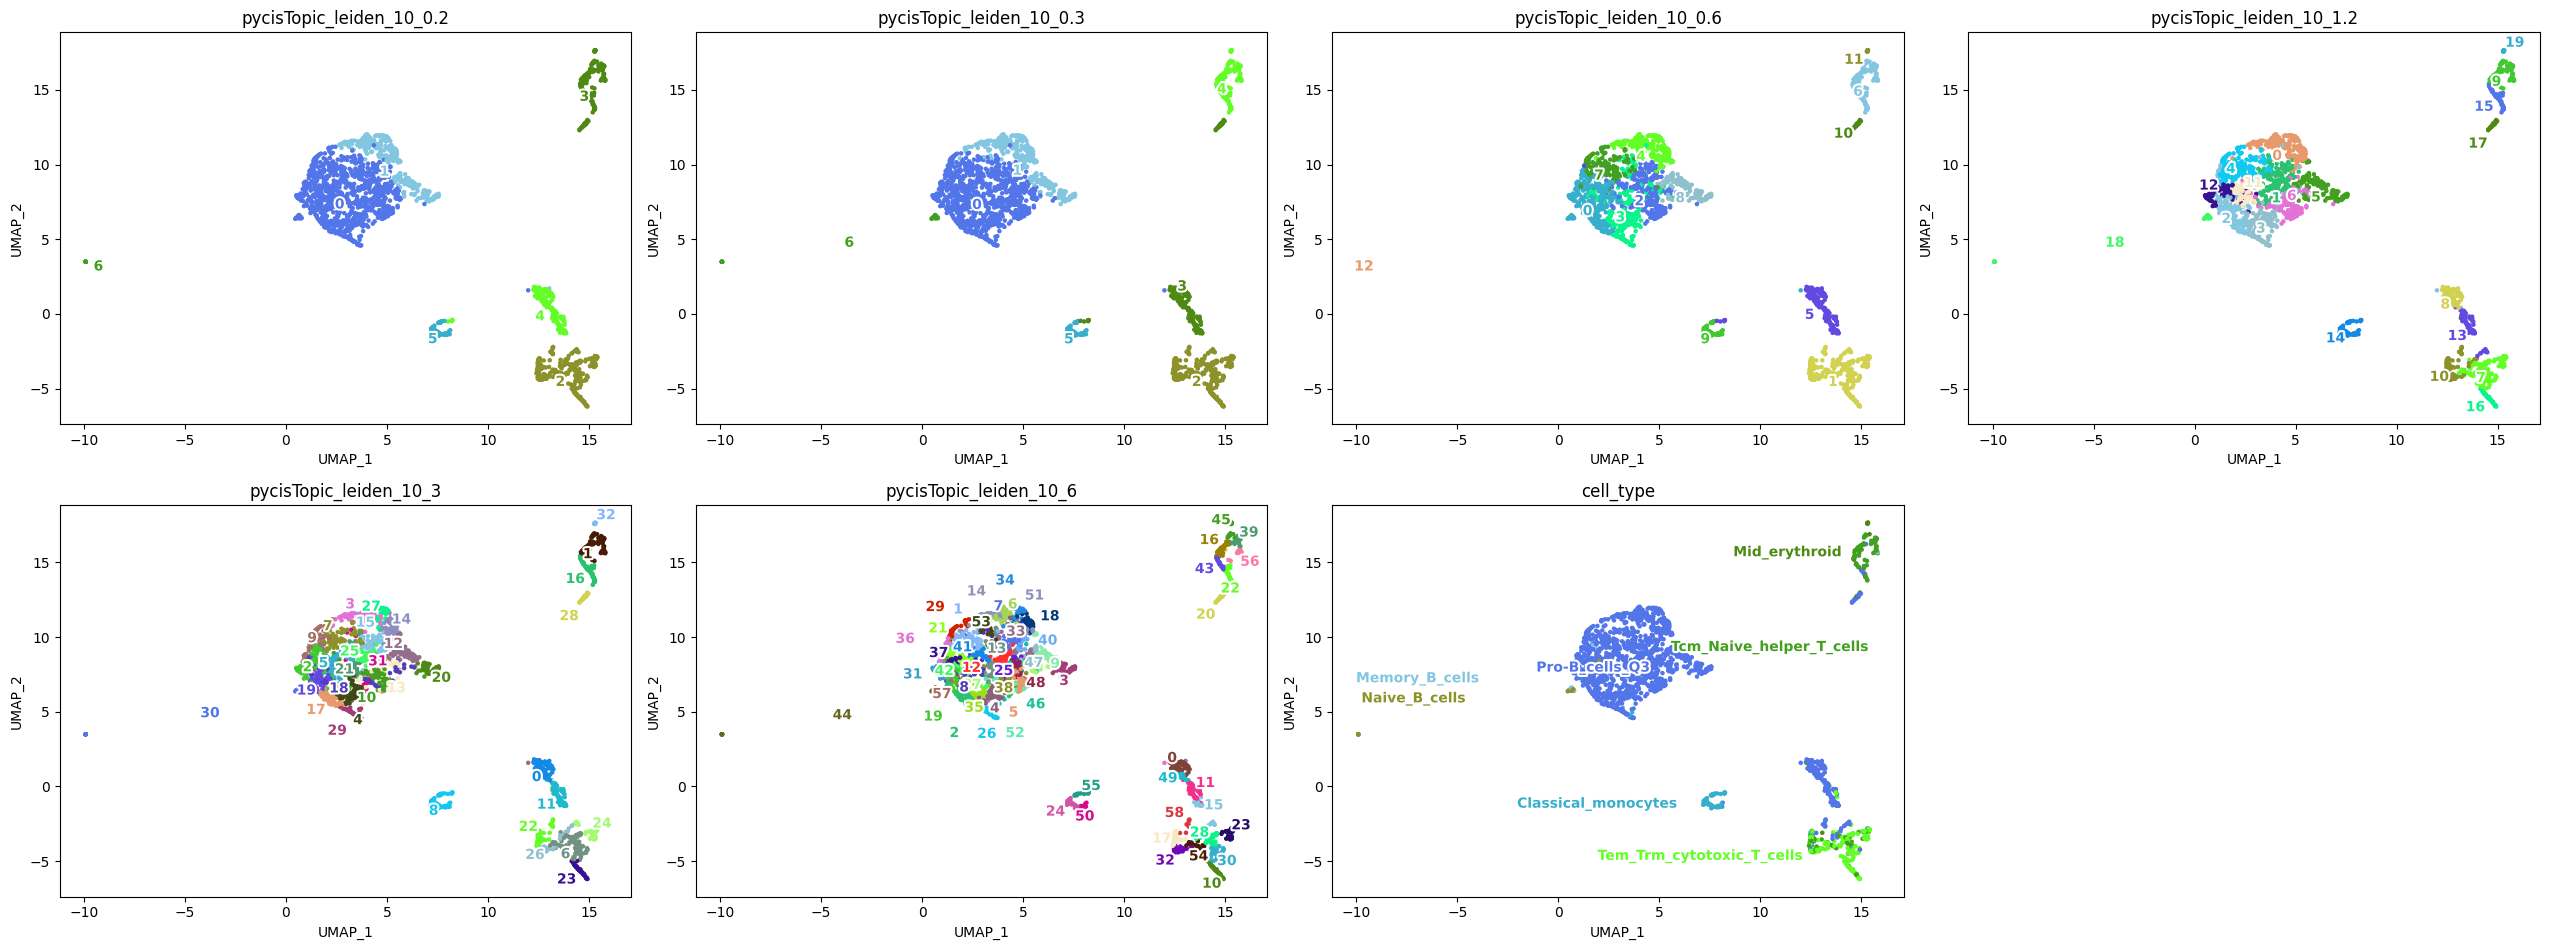

In [20]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['pycisTopic_leiden_10_0.2', 'pycisTopic_leiden_10_0.3','pycisTopic_leiden_10_0.6', 'pycisTopic_leiden_10_1.2', 'pycisTopic_leiden_10_3','pycisTopic_leiden_10_6','cell_type'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

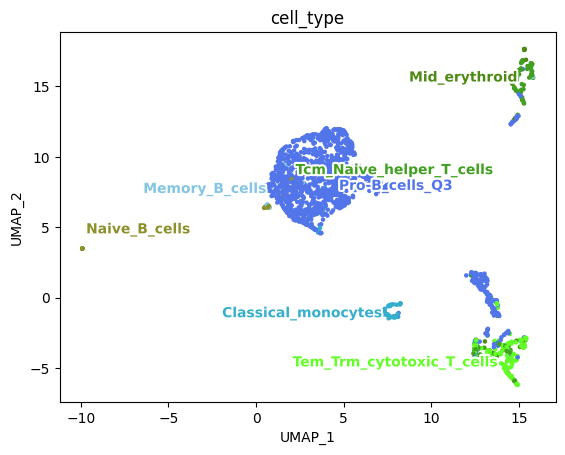

In [21]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['cell_type'],
    target='cell',
    text_size=10,
    dot_size=5)

In [22]:
cistopic_obj.cell_data['is_nan'] = cistopic_obj.cell_data['cell_type'].isna()
cistopic_obj.cell_data['is_nan'].value_counts()

False    1947
True      161
Name: is_nan, dtype: int64

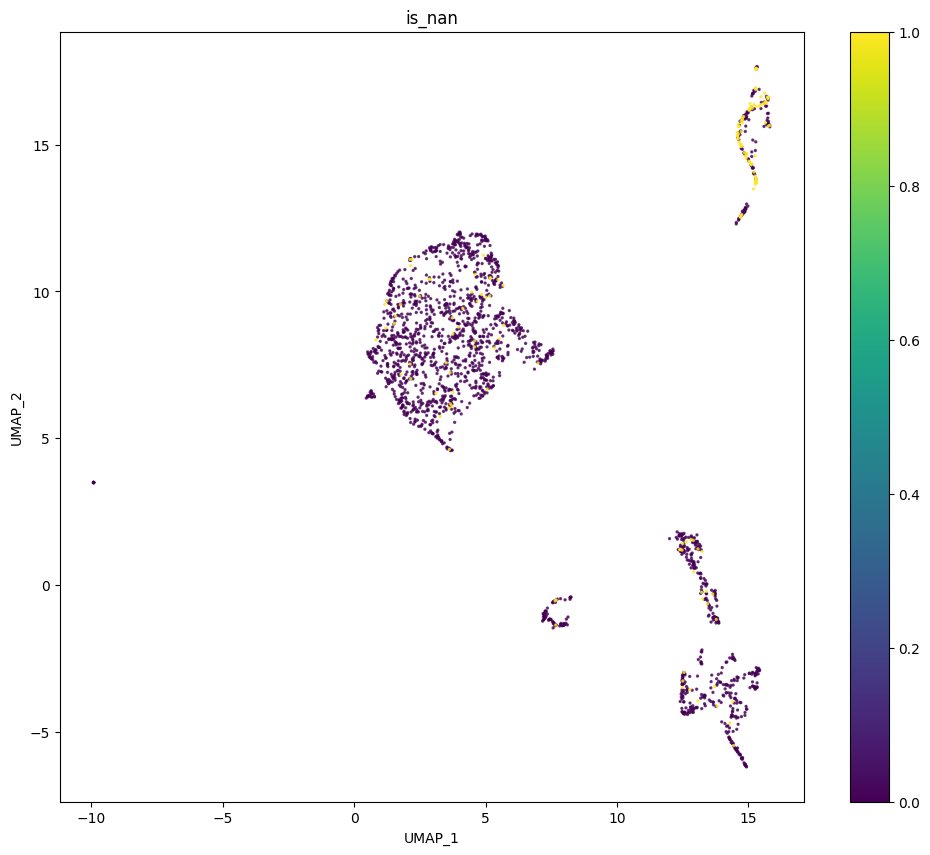

In [23]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['is_nan'],
    remove_nan = False,
    show_label = False,
    target='cell',
    text_size=10,
    dot_size=2,
    alpha = 0.7,
    figsize = (12,10))



# Impute missing cell type labels

Some cells do not have RNA counterpart and hence no cell type annotation. I use KNN = 5 on UMAP projection to impute the missing cell types. 

In [24]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

label = 'cell_type_all'

# Extract UMAP coordinates and cell type labels
cistopic_obj.cell_data[label] = cistopic_obj.cell_data['cell_type'].copy()
umap_coords = cistopic_obj.projections['cell']['UMAP']
cell_types = cistopic_obj.cell_data[label]  


missing_mask = cell_types.isna()

# split
X_labeled = umap_coords[~missing_mask]
y_labeled = cell_types[~missing_mask]
X_unlabeled = umap_coords[missing_mask]

#  KNN classifier on labeled data
knn = KNeighborsClassifier(n_neighbors=5)  
knn.fit(X_labeled, y_labeled)


imputed_labels = knn.predict(X_unlabeled) # predict


cistopic_obj.cell_data.loc[missing_mask, label] = imputed_labels

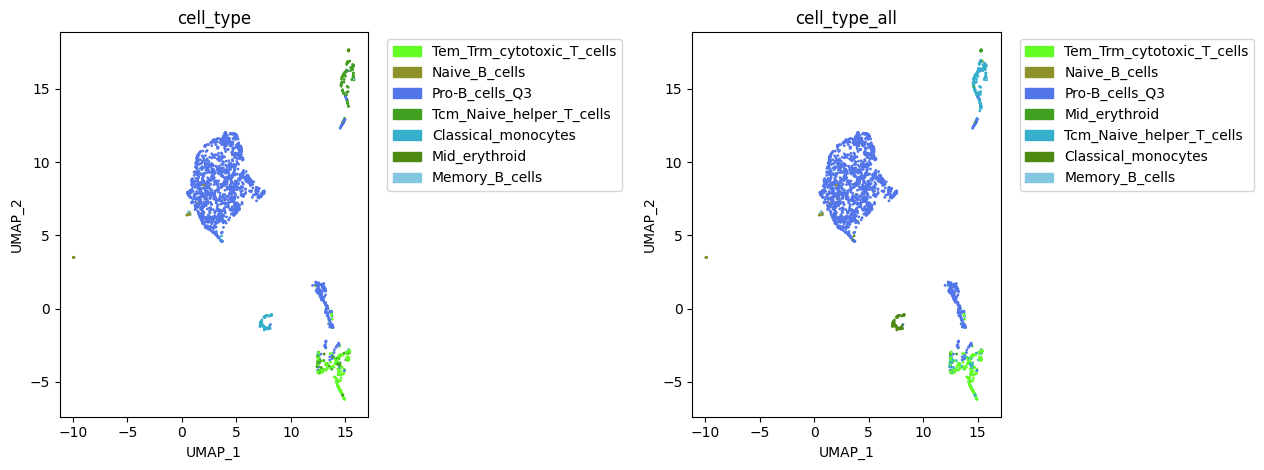

In [25]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['cell_type','cell_type_all'],
    target='cell', num_columns=2,
    text_size=3,
    show_label = False,
    show_legend= True,
    dot_size=1)

In [26]:
cistopic_obj.cell_data.cell_type.value_counts()

Pro-B_cells_Q3               1496
Tem_Trm_cytotoxic_T_cells     183
Tcm_Naive_helper_T_cells      140
Classical_monocytes            79
Naive_B_cells                  19
Memory_B_cells                 17
Mid_erythroid                  13
Name: cell_type, dtype: int64

In [27]:
cistopic_obj.cell_data.cell_type_all.value_counts()

Pro-B_cells_Q3               1569
Tcm_Naive_helper_T_cells      213
Tem_Trm_cytotoxic_T_cells     190
Classical_monocytes            82
Naive_B_cells                  19
Mid_erythroid                  18
Memory_B_cells                 17
Name: cell_type_all, dtype: int64

In [28]:
subset = cistopic_obj.cell_data[cistopic_obj.cell_data['cell_type'].isna()]  # check the predicted cell types
subset

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,barcode_rank,total_fragments_count,log10_total_fragments_count,unique_fragments_count,log10_unique_fragments_count,...,cell_type,sample,pycisTopic_leiden_10_0.2,pycisTopic_leiden_10_0.3,pycisTopic_leiden_10_0.6,pycisTopic_leiden_10_1.2,pycisTopic_leiden_10_3,pycisTopic_leiden_10_6,is_nan,cell_type_all
CTAATTGAGCGATACT-1-Q3___Q3,2144,3.331225,1963,3.29292,Q3,1693,6161,3.789722,3367,3.527372,...,NaN,NaN,3,4,6,15,16,43,True,Tcm_Naive_helper_T_cells
ACACGGACAGCTCAAC-1-Q3___Q3,6292,3.798789,5527,3.742489,Q3,408,29218,4.465665,16073,4.206124,...,NaN,NaN,3,4,11,19,32,45,True,Mid_erythroid
GGTGTCCAGCGGCTGT-1-Q3___Q3,9820,3.992111,8316,3.919914,Q3,508,23894,4.378307,13406,4.127332,...,NaN,NaN,1,1,4,0,14,51,True,Pro-B_cells_Q3
CTACCGGCAAGGATTA-1-Q3___Q3,9265,3.966845,7899,3.897572,Q3,443,27810,4.444217,15154,4.180556,...,NaN,NaN,4,3,5,17,28,20,True,Pro-B_cells_Q3
TTGTTTGGTATTTGCC-1-Q3___Q3,3264,3.51375,2877,3.45894,Q3,944,13743,4.138113,7741,3.888853,...,NaN,NaN,3,4,6,9,1,39,True,Tcm_Naive_helper_T_cells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCAAGTATCATGCTTT-1-Q3___Q3,1151,3.061075,1010,3.004321,Q3,1937,4529,3.656098,2553,3.407221,...,NaN,NaN,3,4,6,15,16,22,True,Tcm_Naive_helper_T_cells
AATTTGCCACACTAAT-1-Q3___Q3,1329,3.123525,1187,3.074451,Q3,1967,4395,3.643058,2473,3.393400,...,NaN,NaN,3,4,6,15,16,22,True,Tcm_Naive_helper_T_cells
ATATGCTCAATTGAGA-1-Q3___Q3,2691,3.429914,2266,3.35526,Q3,1359,8551,3.932068,4727,3.674677,...,NaN,NaN,3,4,6,15,16,43,True,Tcm_Naive_helper_T_cells
CAAAGGATCATCCACC-1-Q3___Q3,2094,3.320977,1861,3.269746,Q3,1623,6412,3.807061,3645,3.561817,...,NaN,NaN,5,5,9,14,8,24,True,Classical_monocytes


In [29]:
subset.cell_type_all.value_counts()

Tcm_Naive_helper_T_cells     73
Pro-B_cells_Q3               73
Tem_Trm_cytotoxic_T_cells     7
Mid_erythroid                 5
Classical_monocytes           3
Name: cell_type_all, dtype: int64

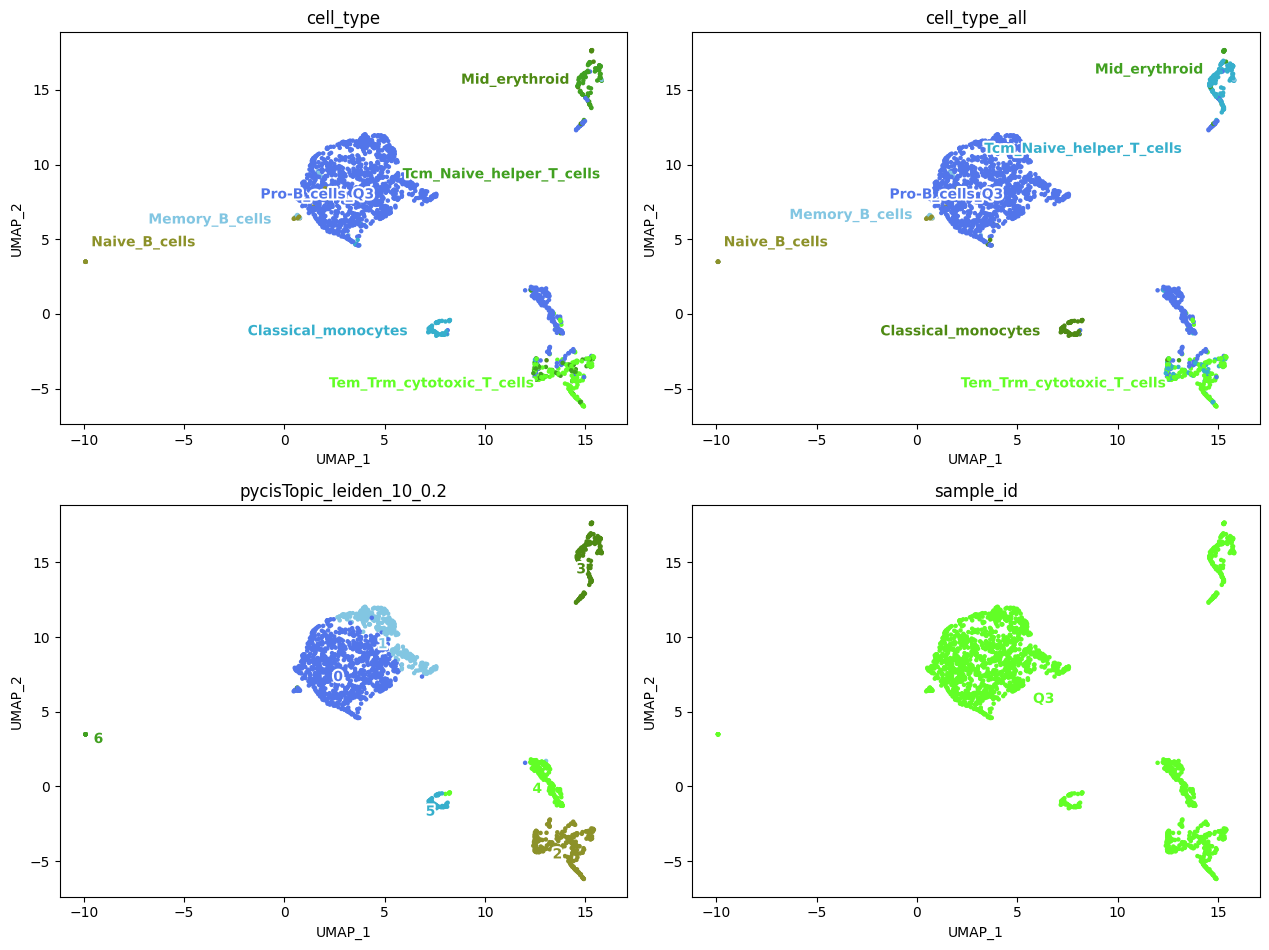

In [30]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['cell_type','cell_type_all','pycisTopic_leiden_10_0.2','sample_id'],
    target='cell', num_columns=2,
    text_size=10,
    dot_size=5)

In [31]:
cistopic_obj.cell_data['sample_id'].isna().sum()

0

In [32]:
cistopic_obj.cell_data['cell_type'].isna().sum() # there is  161 cells that do not have RNA counterpart, or RNA COUNTERPART WAS TOO RARE

161

In [33]:
cistopic_obj.cell_data

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,barcode_rank,total_fragments_count,log10_total_fragments_count,unique_fragments_count,log10_unique_fragments_count,...,cell_type,sample,pycisTopic_leiden_10_0.2,pycisTopic_leiden_10_0.3,pycisTopic_leiden_10_0.6,pycisTopic_leiden_10_1.2,pycisTopic_leiden_10_3,pycisTopic_leiden_10_6,is_nan,cell_type_all
ACGCAAGCAGGAATCG-1-Q3___Q3,20049,4.302093,14510,4.161667,Q3,190,55419,4.743667,30767,4.488099,...,Tem_Trm_cytotoxic_T_cells,Q3,4,3,5,13,11,15,False,Tem_Trm_cytotoxic_T_cells
AACTACTCAAGTCGCT-1-Q3___Q3,6785,3.83155,5660,3.752816,Q3,692,18389,4.264582,10676,4.028449,...,Tcm_Naive_helper_T_cells,Q3,3,4,6,9,1,39,False,Tcm_Naive_helper_T_cells
AGCCAGTGTCATAACG-1-Q3___Q3,9067,3.957464,7922,3.898835,Q3,403,29614,4.471512,16228,4.210292,...,Classical_monocytes,Q3,5,5,9,14,8,55,False,Classical_monocytes
AGACAATAGTAACCAC-1-Q3___Q3,2602,3.415307,2403,3.380754,Q3,1455,7644,3.883377,4261,3.629613,...,Pro-B_cells_Q3,Q3,3,3,10,17,28,20,False,Pro-B_cells_Q3
CGATGTCCACGTAATT-1-Q3___Q3,13796,4.139753,11665,4.066885,Q3,215,48331,4.684235,27219,4.434888,...,Pro-B_cells_Q3,Q3,0,0,3,3,4,4,False,Pro-B_cells_Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TATAGCTCATTGCGAC-1-Q3___Q3,1931,3.285782,1811,3.257918,Q3,1936,4791,3.680517,2560,3.408410,...,Pro-B_cells_Q3,Q3,0,0,2,6,10,5,False,Pro-B_cells_Q3
AAACGCGCAACAACAA-1-Q3___Q3,1081,3.033826,1001,3.000434,Q3,2324,2622,3.418798,1519,3.181844,...,Classical_monocytes,Q3,5,5,9,14,8,50,False,Classical_monocytes
CGAGGAAGTGTGAGAG-1-Q3___Q3,1476,3.169086,1377,3.138934,Q3,2156,3512,3.545678,1936,3.287130,...,Tem_Trm_cytotoxic_T_cells,Q3,2,2,1,10,26,32,False,Tem_Trm_cytotoxic_T_cells
AGCCGGTTCGTTACTT-1-Q3___Q3,1291,3.110926,1259,3.100026,Q3,2085,3874,3.588272,2121,3.326745,...,Pro-B_cells_Q3,Q3,0,0,2,1,15,33,False,Pro-B_cells_Q3


In [34]:
# remove NAs in sample_id
cistopic_obj.cell_data['sample_id'] = cistopic_obj.cell_data['sample_id'].fillna(cistopic_obj.cell_data.index.to_series().apply(lambda x: x.split('__')[-1]))
cistopic_obj.cell_data['sample_id'] = cistopic_obj.cell_data['sample_id'].str.replace('_','')
cistopic_obj.cell_data['sample_id'].isna().sum()

0

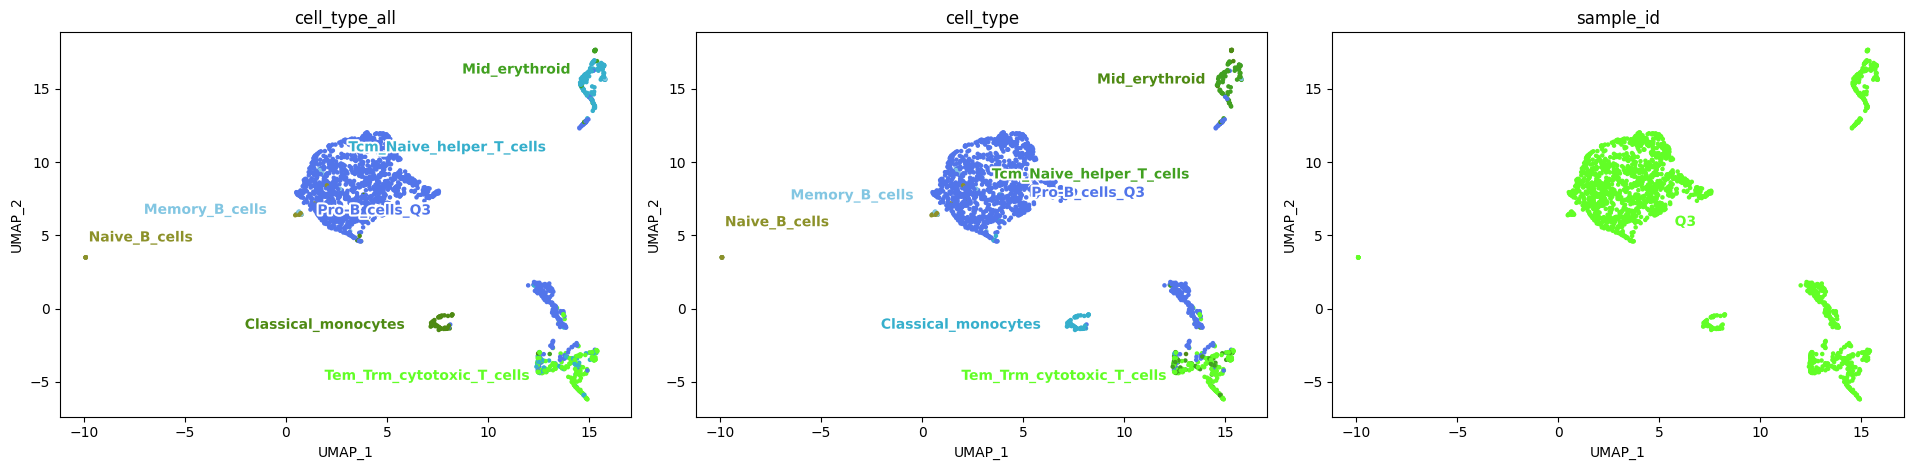

In [35]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['cell_type_all','cell_type', 'sample_id'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

In [36]:
cistopic_obj.cell_data.tss_enrichment.max()

53.04660887885489

In [37]:
cistopic_obj.cell_data.tss_enrichment.min()

10.010800525983505

In [38]:
cistopic_obj.cell_data.tss_enrichment.median()

23.790455397689577

In [39]:
cistopic_obj.cell_data.fraction_of_fragments_in_peaks.median()

0.7039576888906183

In [40]:
cistopic_obj.cell_data.log10_unique_fragments_count.median()

3.719082067179616

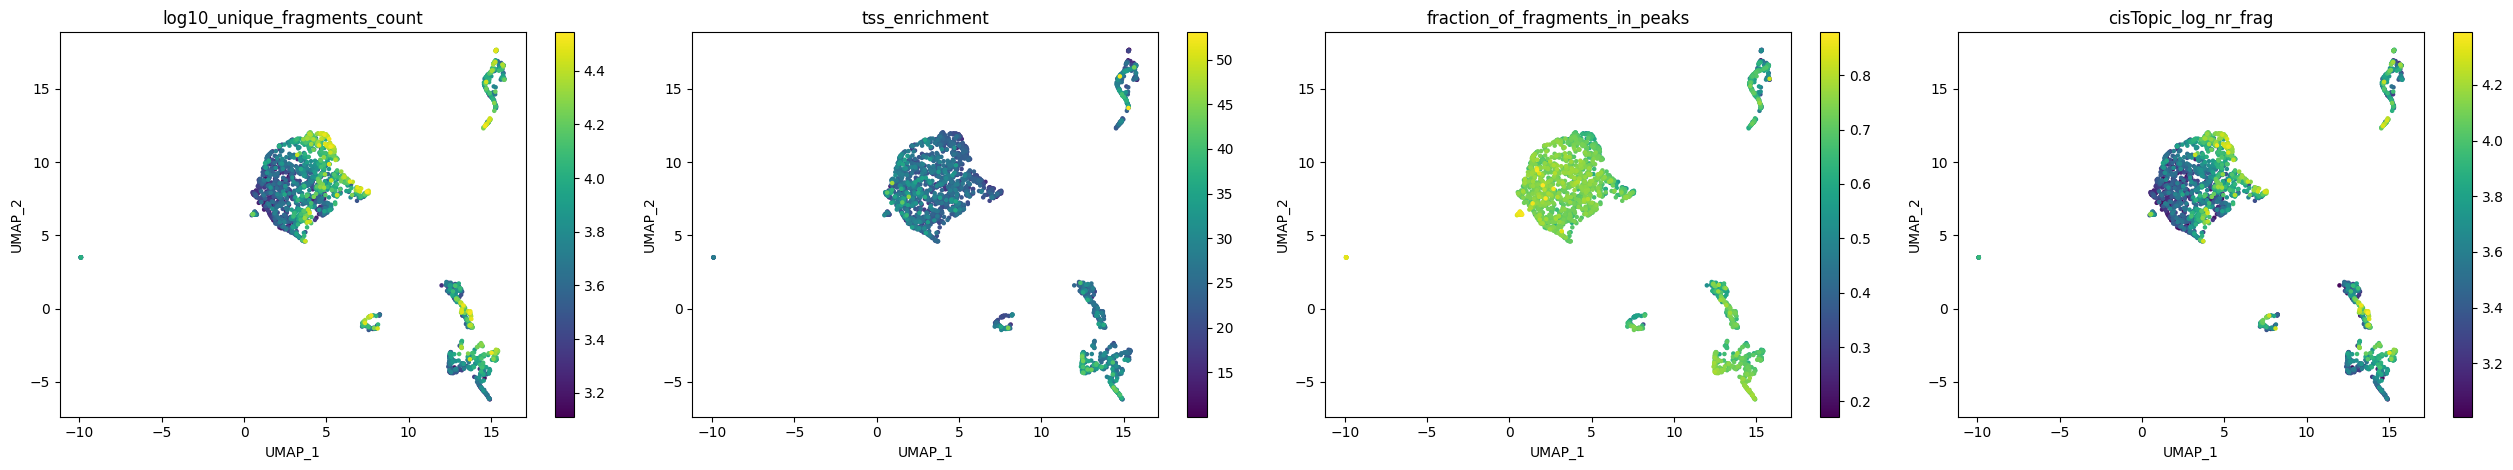

In [41]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['log10_unique_fragments_count', 'tss_enrichment', 'fraction_of_fragments_in_peaks', 'cisTopic_log_nr_frag'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

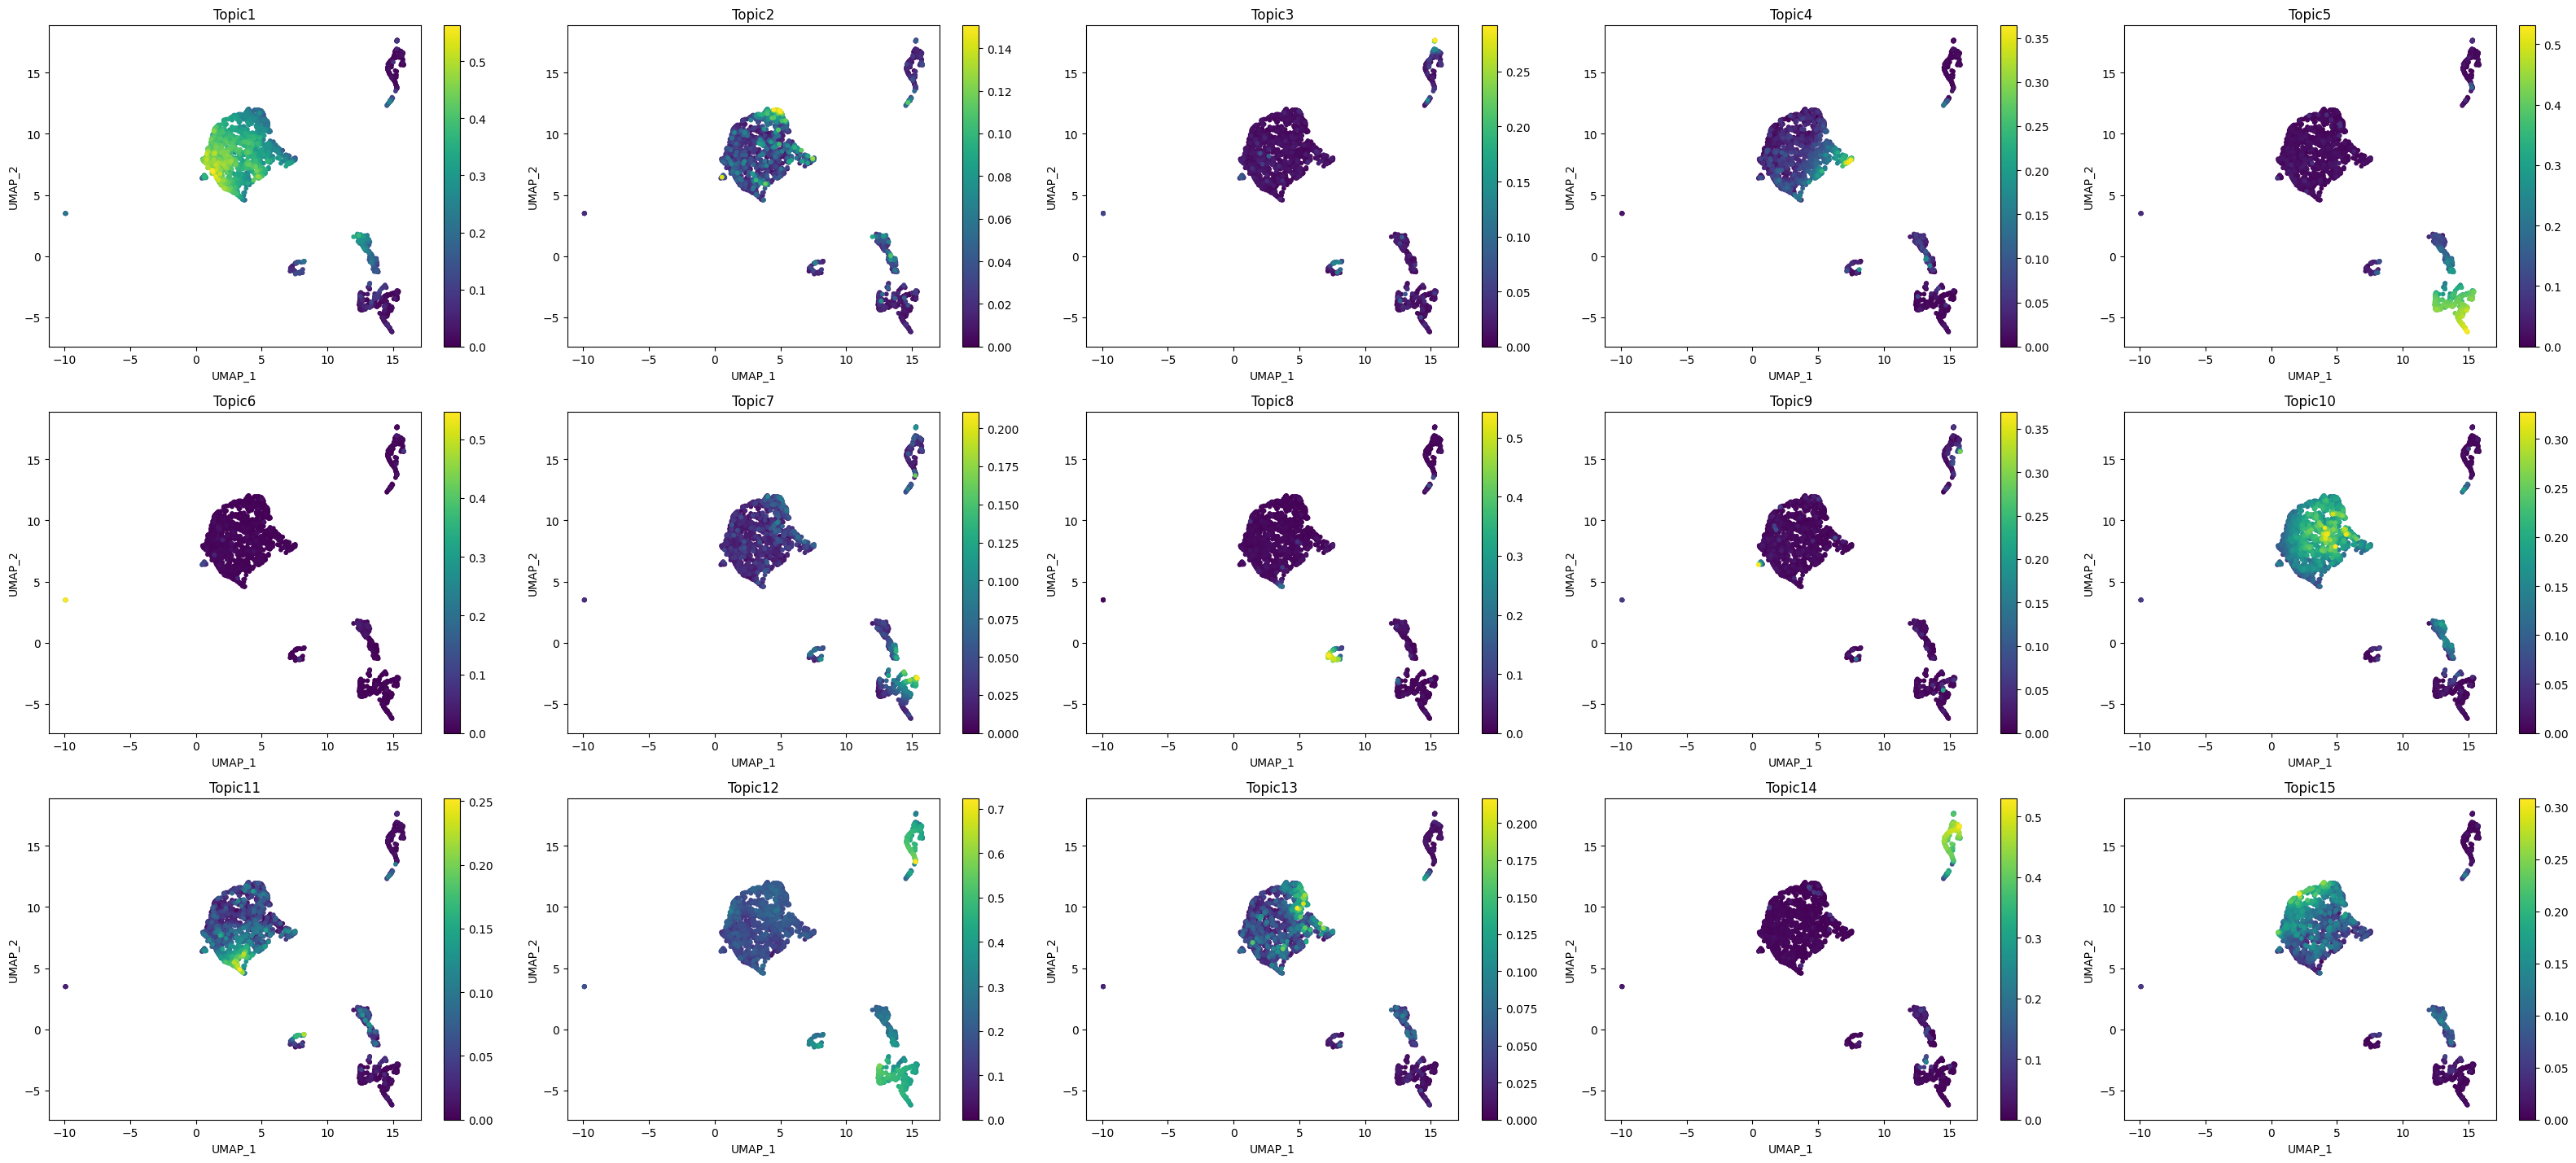

In [42]:
# cell topic contributions- 
plot_topic(
    cistopic_obj,
    reduction_name = 'UMAP',
    target = 'cell',
    num_columns=5
)

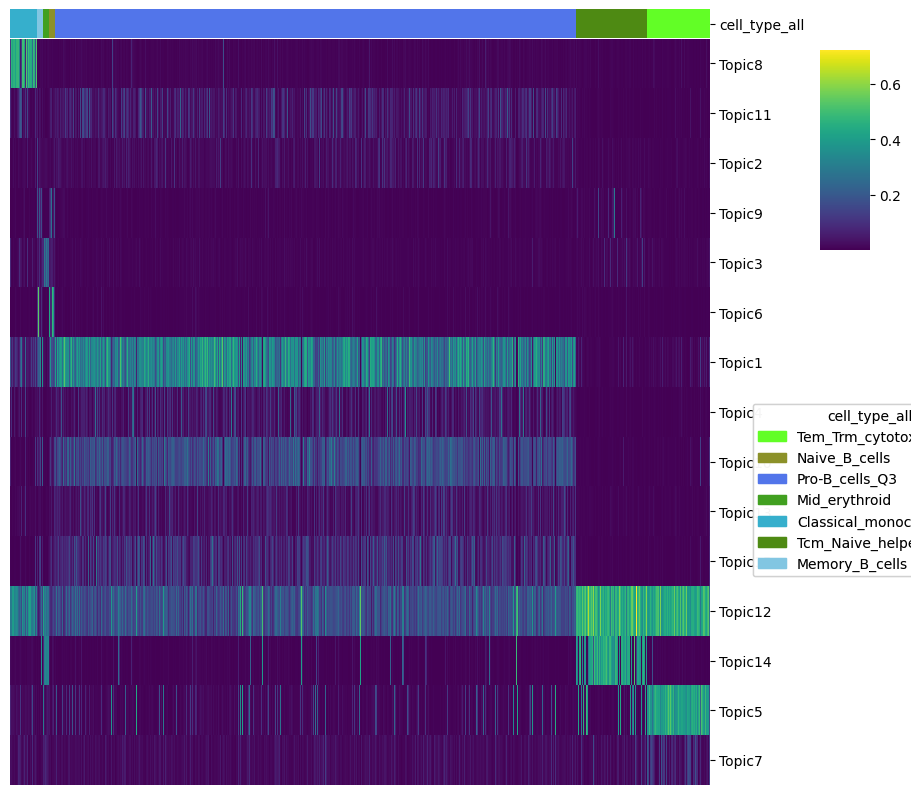

In [43]:
cell_topic_heatmap(
    cistopic_obj,
    variables = ['cell_type_all'],
    scale = False,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    figsize = (10, 10)
)

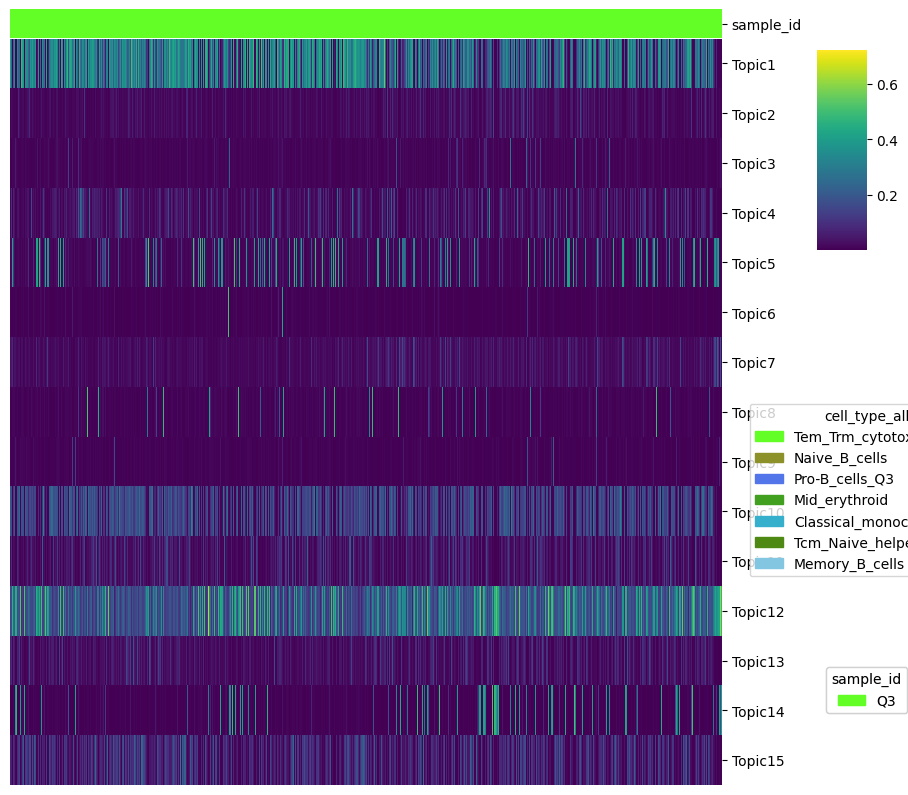

In [44]:
cell_topic_heatmap(
    cistopic_obj,
    variables = ['sample_id'],
    scale = False,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    figsize = (10, 10)
)

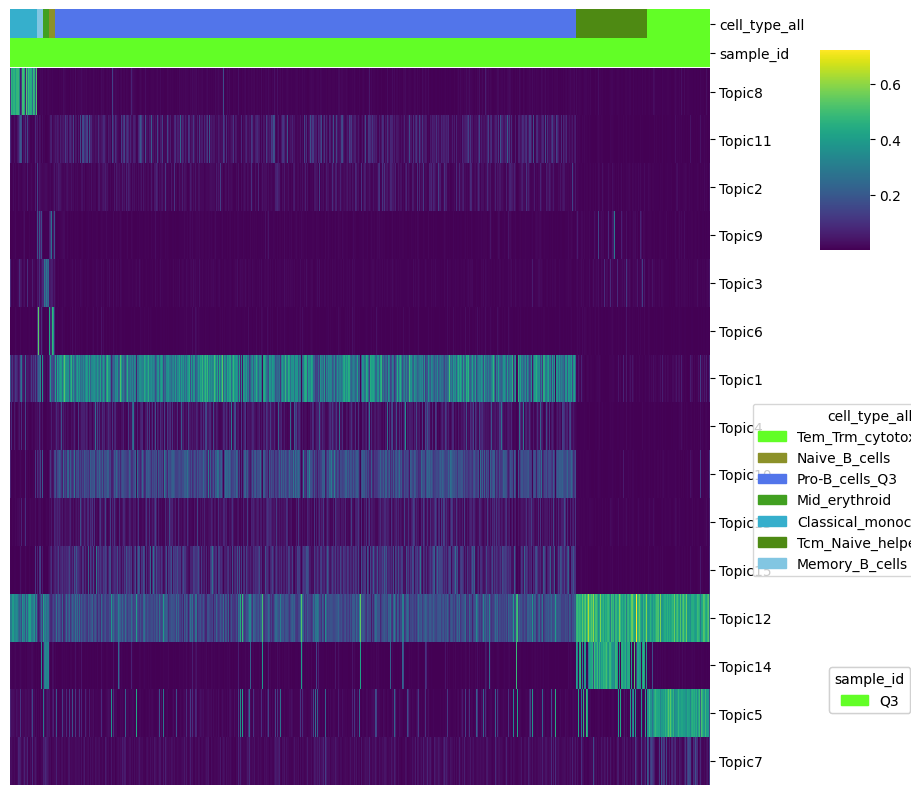

In [45]:
cell_topic_heatmap(
    cistopic_obj,
    variables = ['cell_type_all','sample_id'],
    scale = False,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    figsize = (10, 10)
)

# Topic binarization

In [46]:
from pycisTopic.topic_binarization import binarize_topics

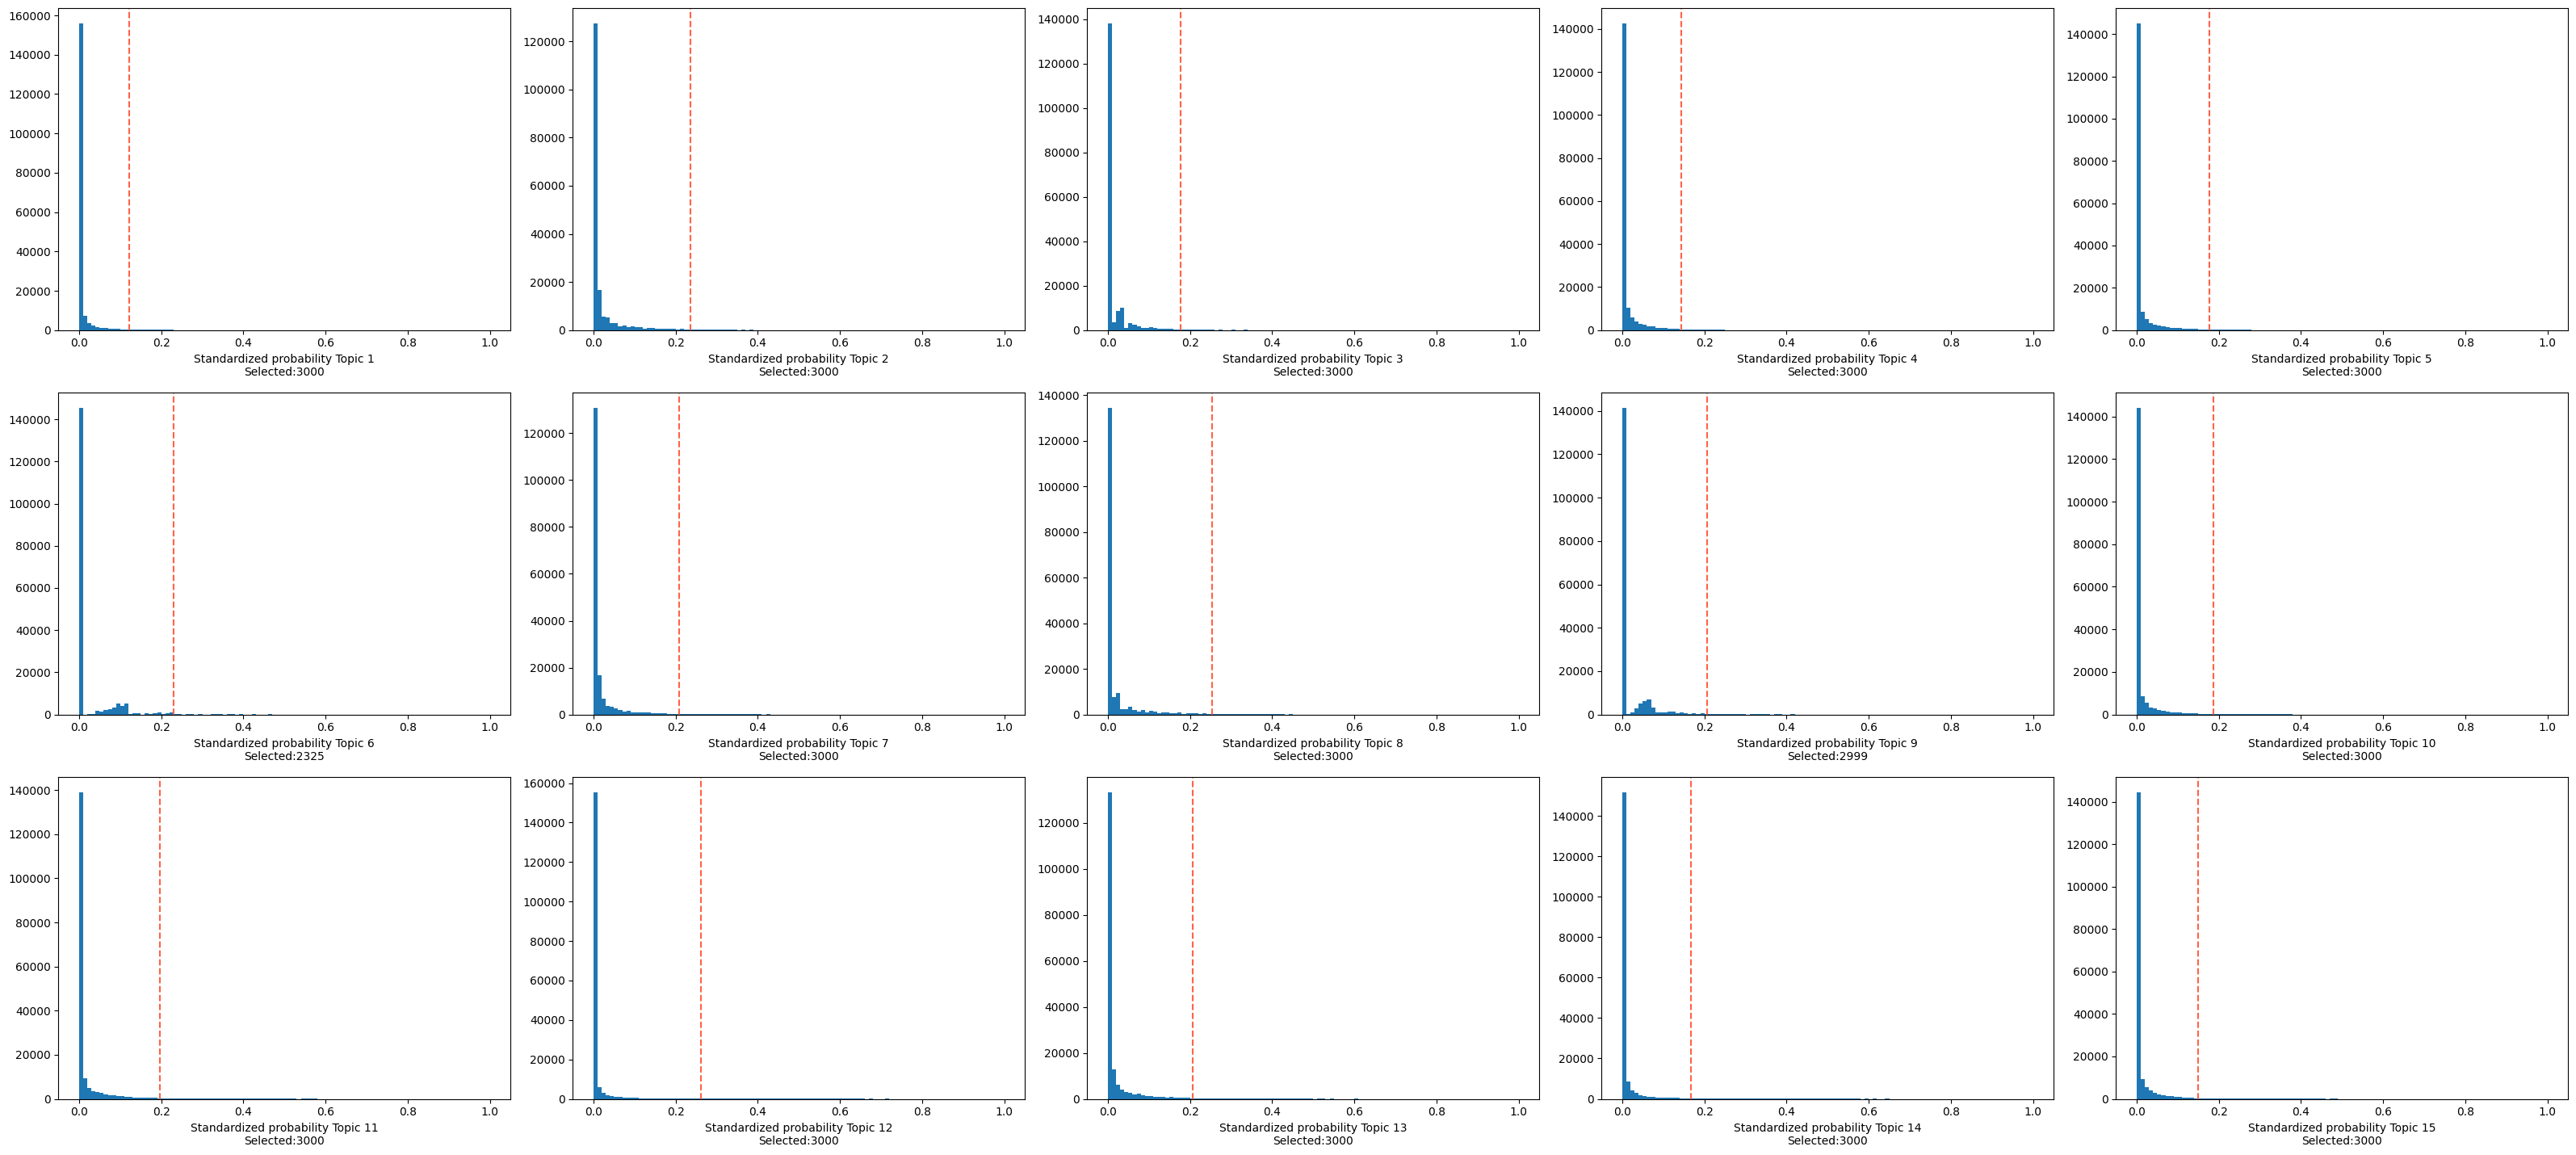

In [47]:
region_bin_topics_top_3k = binarize_topics(
    cistopic_obj, method='ntop', ntop = 3_000,
    plot=True, num_columns=5
)

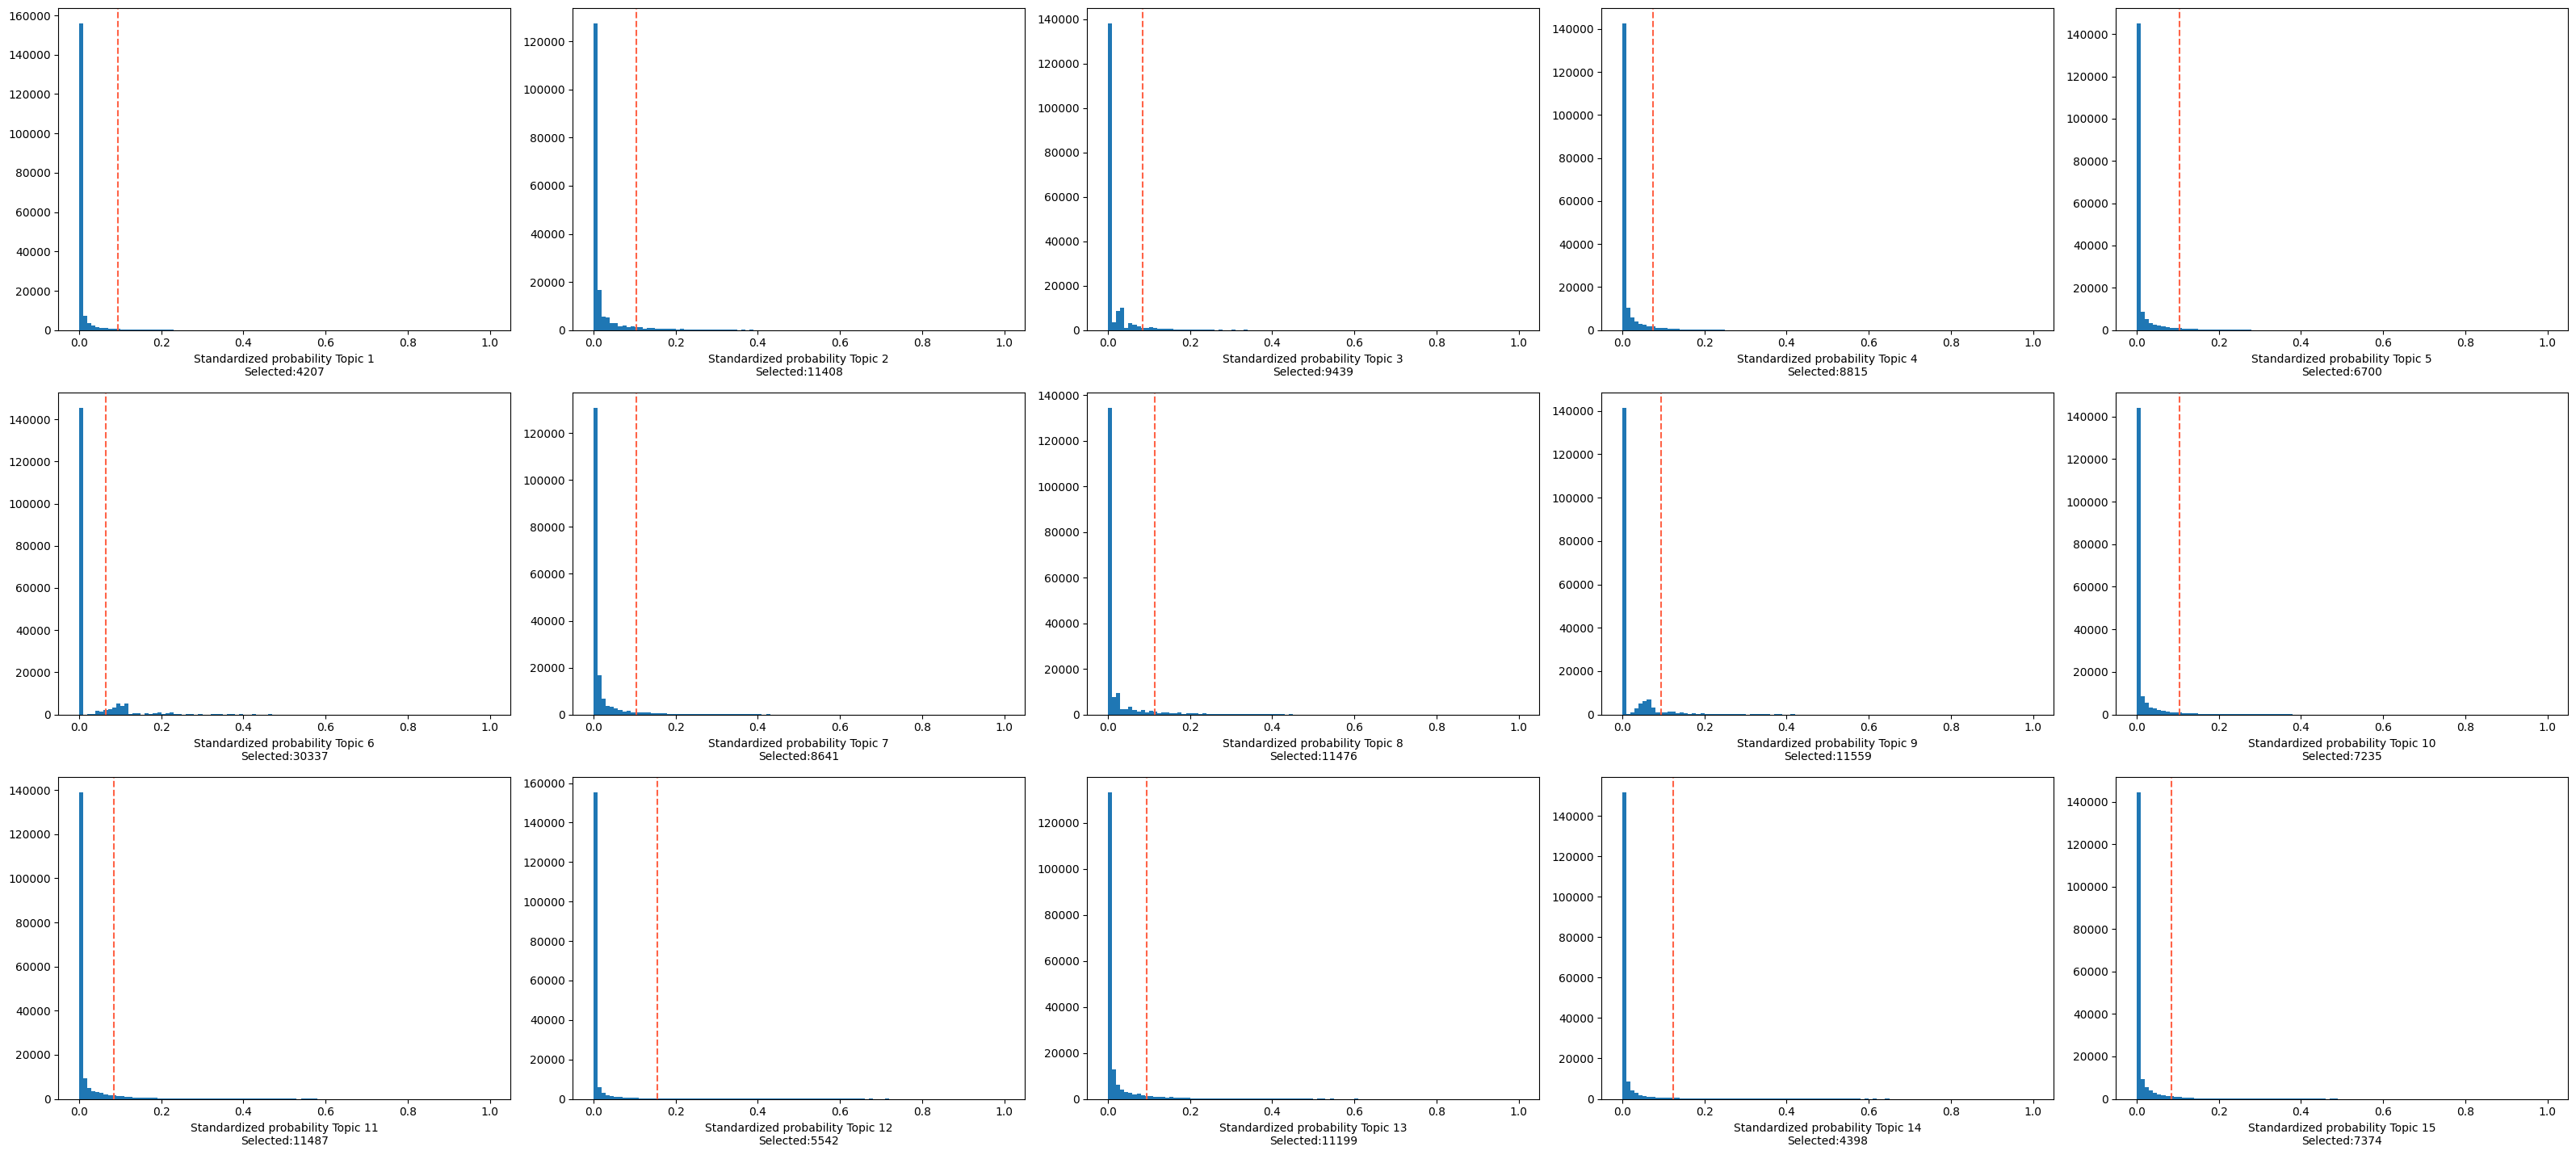

In [48]:
region_bin_topics_otsu = binarize_topics(
    cistopic_obj, method='otsu',
    plot=True, num_columns=5
)

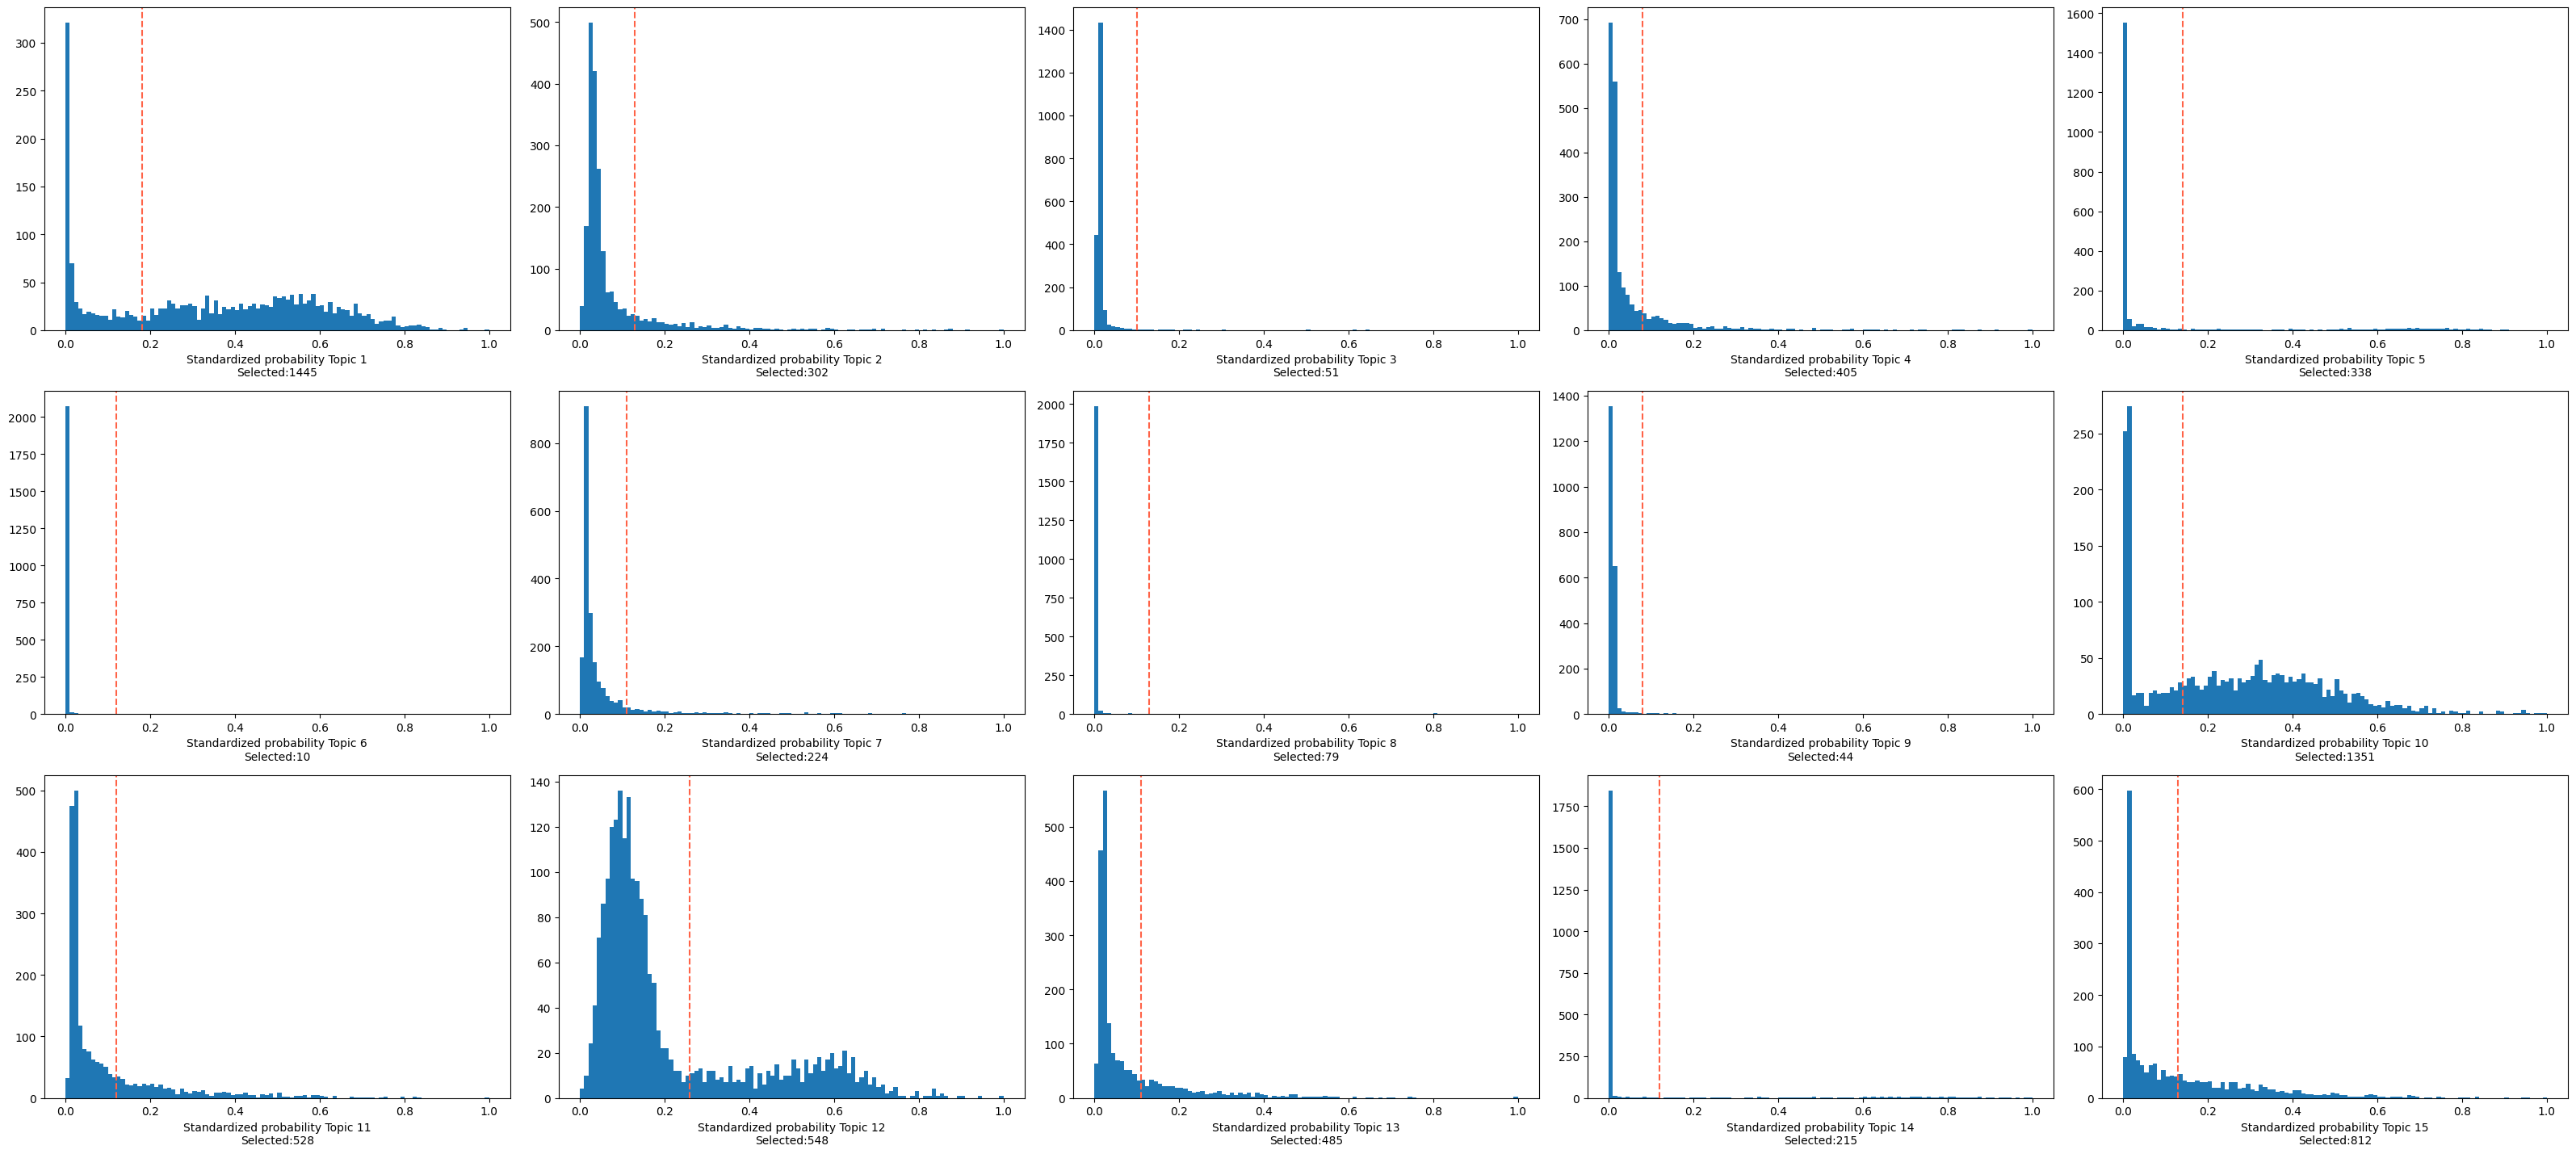

In [49]:
binarized_cell_topic = binarize_topics(
    cistopic_obj,
    target='cell',
    method='li',
    plot=True,
    num_columns=5, nbins=100)

In [50]:
from pycisTopic.topic_qc import compute_topic_metrics, plot_topic_qc, topic_annotation
import matplotlib.pyplot as plt
from pycisTopic.utils import fig2img

In [51]:
topic_qc_metrics = compute_topic_metrics(cistopic_obj)

In [52]:
fig_dict={}
fig_dict['CoherenceVSAssignments']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Log10_Assignments', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['AssignmentsVSCells_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Log10_Assignments', var_y='Cells_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSCells_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Cells_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSRegions_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Regions_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSMarginal_dist']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Marginal_topic_dist', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSGini_index']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Gini_index', var_color='Gini_index', plot=False, return_fig=True)

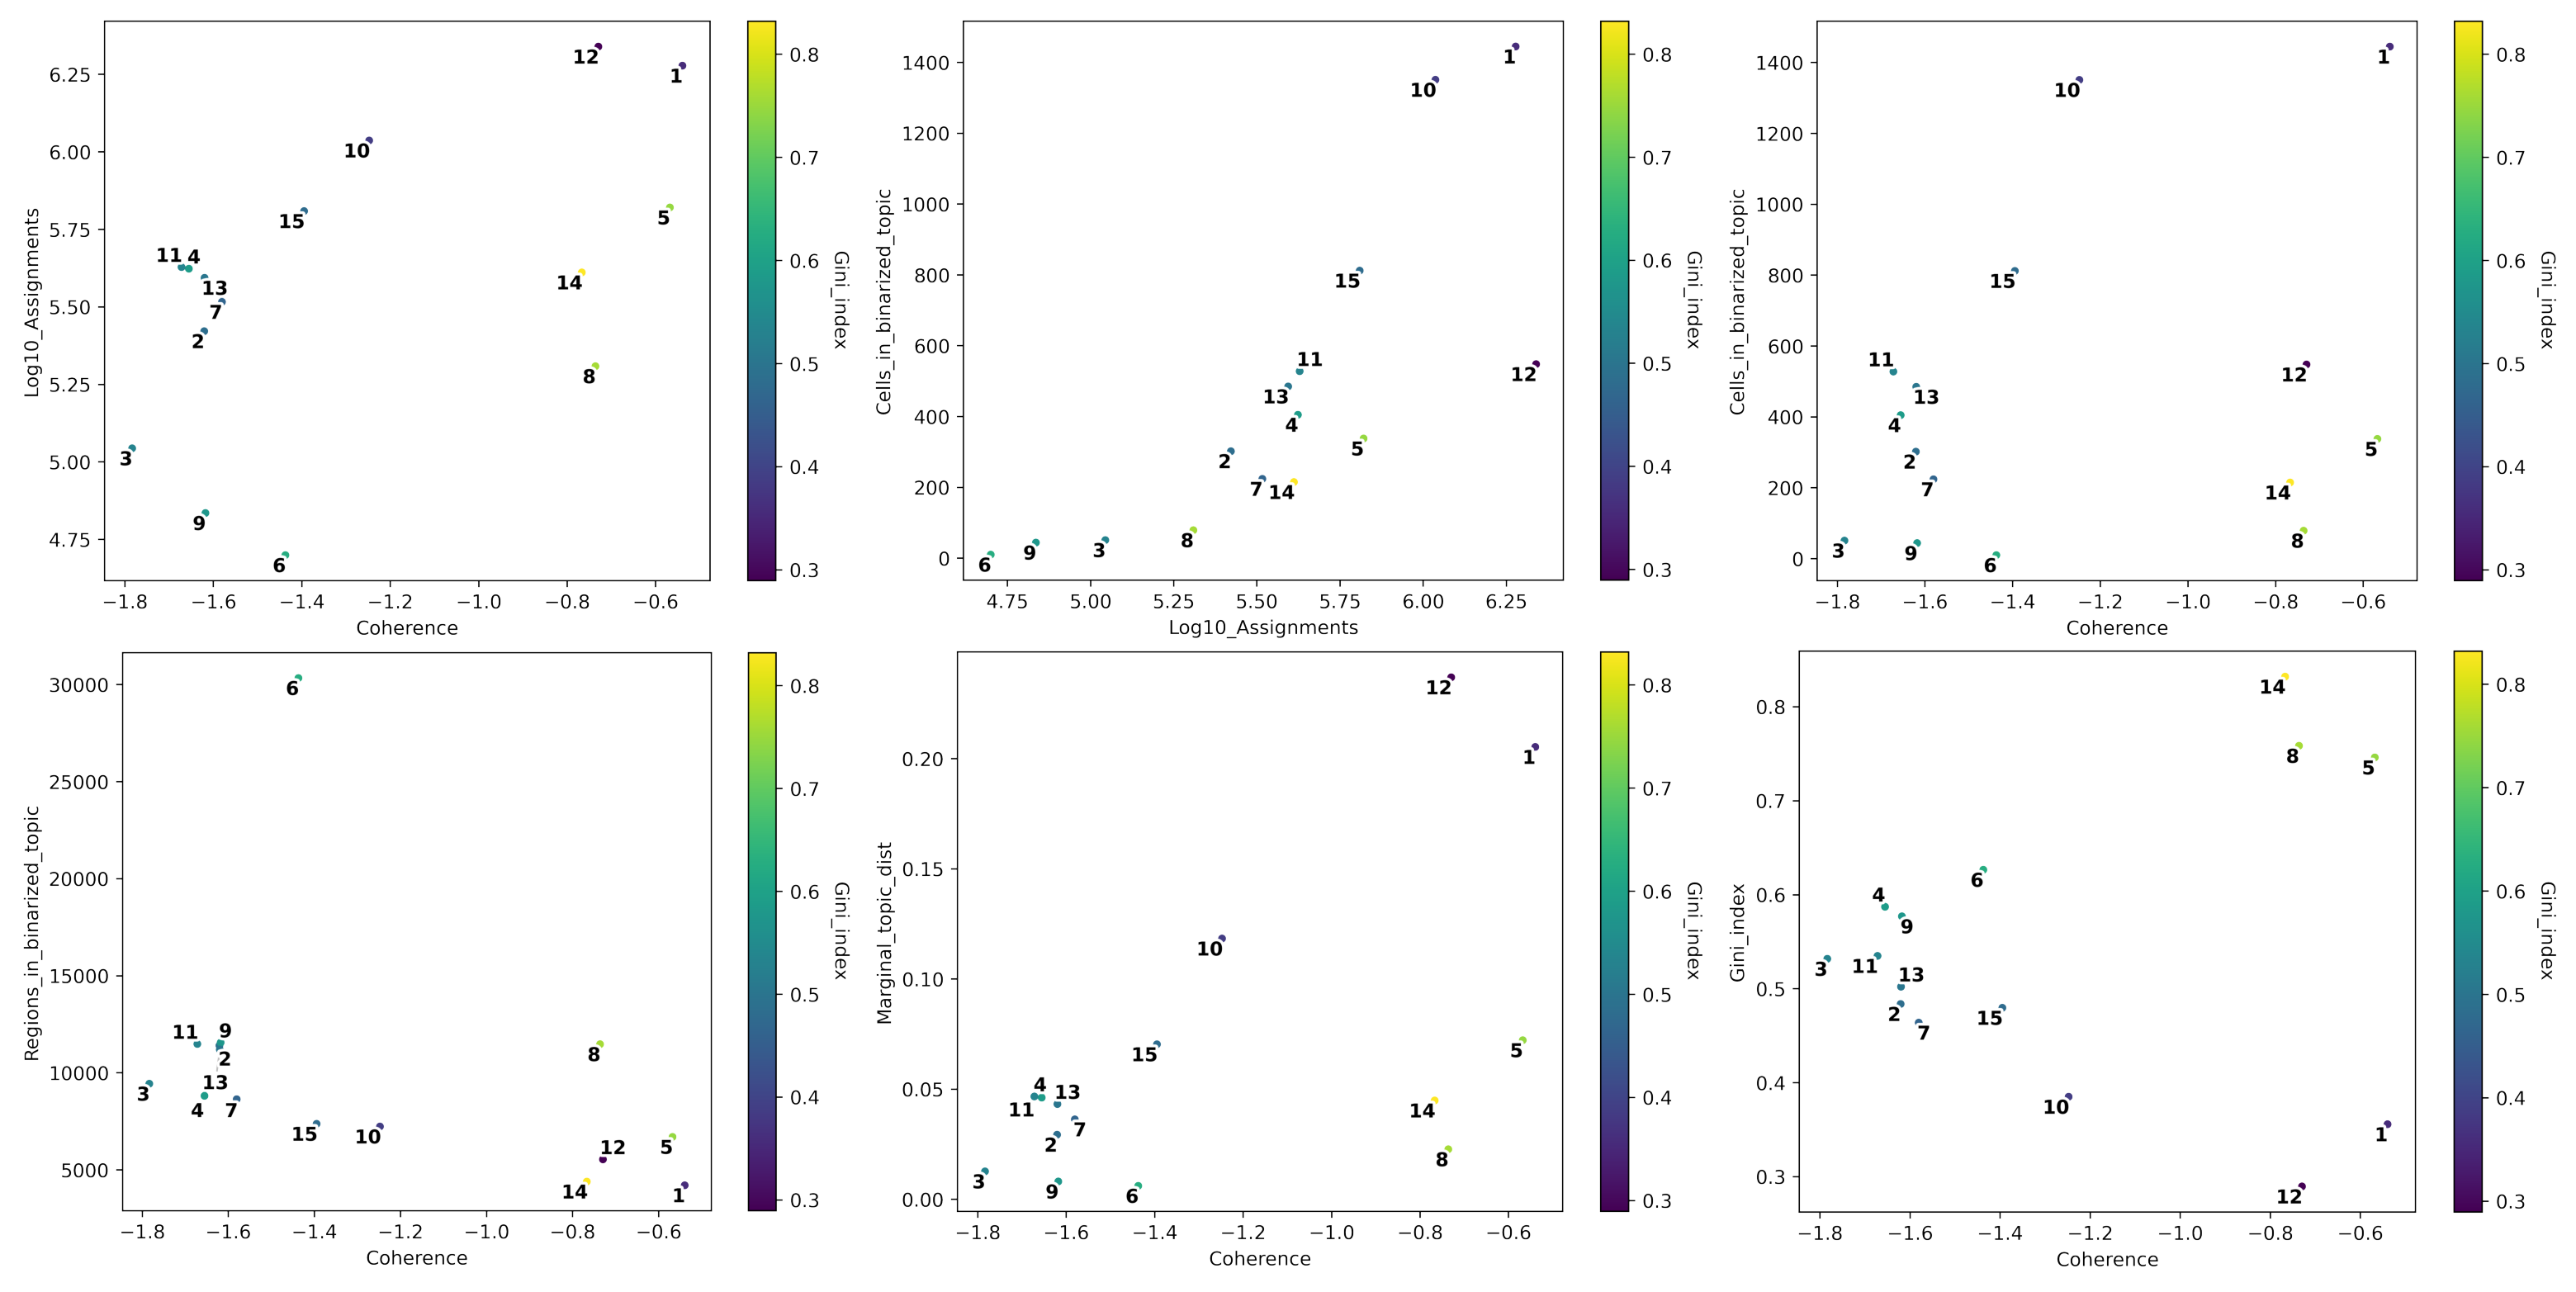

In [53]:
# Plot topic stats in one figure
fig=plt.figure(figsize=(40, 43))
i = 1
for fig_ in fig_dict.keys():
    plt.subplot(2, 3, i)
    img = fig2img(fig_dict[fig_]) #To convert figures to png to plot together, see .utils.py. This converts the figure to png.
    plt.imshow(img)
    plt.axis('off')
    i += 1
plt.subplots_adjust(wspace=0, hspace=-0.70)
plt.show()

Number of assignments

Topic coherence (Mimno et al., 2011): Measures to which extent high scoring regions in the topic are actually co-accessible in the original data. If it is low it indicates that the topic is rather random. The higher, the better is a topic.

The marginal topic distribution: Indicates how much each topic contributes to the model. The higher, the better is a topic.

The gini index: Value between 0 and 1, that indicates the specificity of topics (0: General, 1:Specific)

If topics have been binarized, the number of regions/cells per topic will be added.

# Cell type - topic annotation

In [54]:
topic_annot = topic_annotation(
    cistopic_obj,
    annot_var='cell_type_all',
    binarized_cell_topic=binarized_cell_topic,
    general_topic_thr = 0.2
)

/opt/venv/lib/python3.11/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: divide by zero encountered in scalar divide
  zstat = value / std


In [55]:
topic_annot

,cell_type_all,Ratio_cells_in_topic,Ratio_group_in_population,is_general
Topic1,Pro-B_cells_Q3,0.685484,0.744307,False
Topic2,Pro-B_cells_Q3,0.143264,0.744307,False
Topic3,"Tcm_Naive_helper_T_cells, Mid_erythroid, Class...",0.024194,0.148482,False
Topic4,Pro-B_cells_Q3,0.192125,0.744307,False
Topic5,"Tem_Trm_cytotoxic_T_cells, Tcm_Naive_helper_T_...",0.160342,0.191176,False
Topic6,Naive_B_cells,0.004744,0.009013,False
Topic7,"Tem_Trm_cytotoxic_T_cells, Tcm_Naive_helper_T_...",0.106262,0.238615,False
Topic8,Classical_monocytes,0.037476,0.038899,False
Topic9,"Naive_B_cells, Tcm_Naive_helper_T_cells, Memor...",0.020873,0.118121,False
Topic10,Pro-B_cells_Q3,0.640892,0.744307,False


# DAR

In [56]:
from pycisTopic.diff_features import (
    impute_accessibility,
    normalize_scores,
    find_highly_variable_features,
    find_diff_features
)
import numpy as np

In [57]:
imputed_acc_obj = impute_accessibility(
    cistopic_obj,
    selected_cells=None,
    selected_regions=None,
    scale_factor=10**6
)

2025-07-11 14:08:48,592 cisTopic     INFO     Imputing region accessibility
2025-07-11 14:08:48,593 cisTopic     INFO     Impute region accessibility for regions 0-20000
2025-07-11 14:08:48,804 cisTopic     INFO     Impute region accessibility for regions 20000-40000
2025-07-11 14:08:49,000 cisTopic     INFO     Impute region accessibility for regions 40000-60000
2025-07-11 14:08:49,197 cisTopic     INFO     Impute region accessibility for regions 60000-80000
2025-07-11 14:08:49,394 cisTopic     INFO     Impute region accessibility for regions 80000-100000
2025-07-11 14:08:49,591 cisTopic     INFO     Impute region accessibility for regions 100000-120000
2025-07-11 14:08:49,788 cisTopic     INFO     Impute region accessibility for regions 120000-140000
2025-07-11 14:08:49,985 cisTopic     INFO     Impute region accessibility for regions 140000-160000
2025-07-11 14:08:50,183 cisTopic     INFO     Impute region accessibility for regions 160000-180000
2025-07-11 14:08:50,372 cisTopic     

In [58]:
normalized_imputed_acc_obj = normalize_scores(imputed_acc_obj, scale_factor=10**4)

2025-07-11 14:08:50,376 cisTopic     INFO     Normalizing imputed data
2025-07-11 14:08:52,102 cisTopic     INFO     Done!


2025-07-11 14:08:52,106 cisTopic     INFO     Calculating mean
2025-07-11 14:08:52,473 cisTopic     INFO     Calculating variance


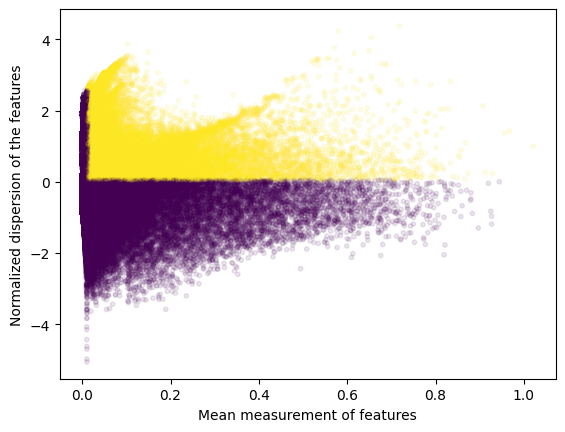

2025-07-11 14:08:59,318 cisTopic     INFO     Done!


In [59]:
variable_regions = find_highly_variable_features(
    normalized_imputed_acc_obj,
    min_disp = 0.05,
    min_mean = 0.0125,
    max_mean = 3,
    max_disp = np.inf,
    n_bins=20,
    n_top_features=None,
    plot=True
)

In [60]:
len(variable_regions)

36686

In [ ]:
markers_dict= find_diff_features(
    cistopic_obj,
    imputed_acc_obj,
    variable='cell_type_all',
    var_features=variable_regions,
    contrasts=None,
    adjpval_thr=0.05,
    log2fc_thr=np.log2(1.5),
    n_cpu=5,
    _temp_dir='/ray_spill',
    split_pattern = '-'
)

2025-07-11 14:09:03,332	INFO worker.py:1724 -- Started a local Ray instance.


2025-07-11 14:09:04,312 cisTopic     INFO     Subsetting data for Classical_monocytes (82 of 2108)
2025-07-11 14:09:08,722 cisTopic     INFO     Computing p-value for Classical_monocytes
2025-07-11 14:09:14,379 cisTopic     INFO     Computing log2FC for Classical_monocytes
2025-07-11 14:09:16,266 cisTopic     INFO     Classical_monocytes done!
2025-07-11 14:09:16,269 cisTopic     INFO     Subsetting data for Memory_B_cells (17 of 2108)
2025-07-11 14:09:16,341 cisTopic     INFO     Computing p-value for Memory_B_cells
2025-07-11 14:09:20,863 cisTopic     INFO     Computing log2FC for Memory_B_cells
2025-07-11 14:09:20,906 cisTopic     INFO     Memory_B_cells done!
2025-07-11 14:09:20,909 cisTopic     INFO     Subsetting data for Mid_erythroid (18 of 2108)
2025-07-11 14:09:20,968 cisTopic     INFO     Computing p-value for Mid_erythroid
2025-07-11 14:09:25,559 cisTopic     INFO     Computing log2FC for Mid_erythroid
2025-07-11 14:09:25,591 cisTopic     INFO     Mid_erythroid done!
2025-0

In [62]:
from pycisTopic.clust_vis import plot_imputed_features

In [63]:
cistopic_obj.cell_data.cell_type_all.value_counts()

Pro-B_cells_Q3               1569
Tcm_Naive_helper_T_cells      213
Tem_Trm_cytotoxic_T_cells     190
Classical_monocytes            82
Naive_B_cells                  19
Mid_erythroid                  18
Memory_B_cells                 17
Name: cell_type_all, dtype: int64

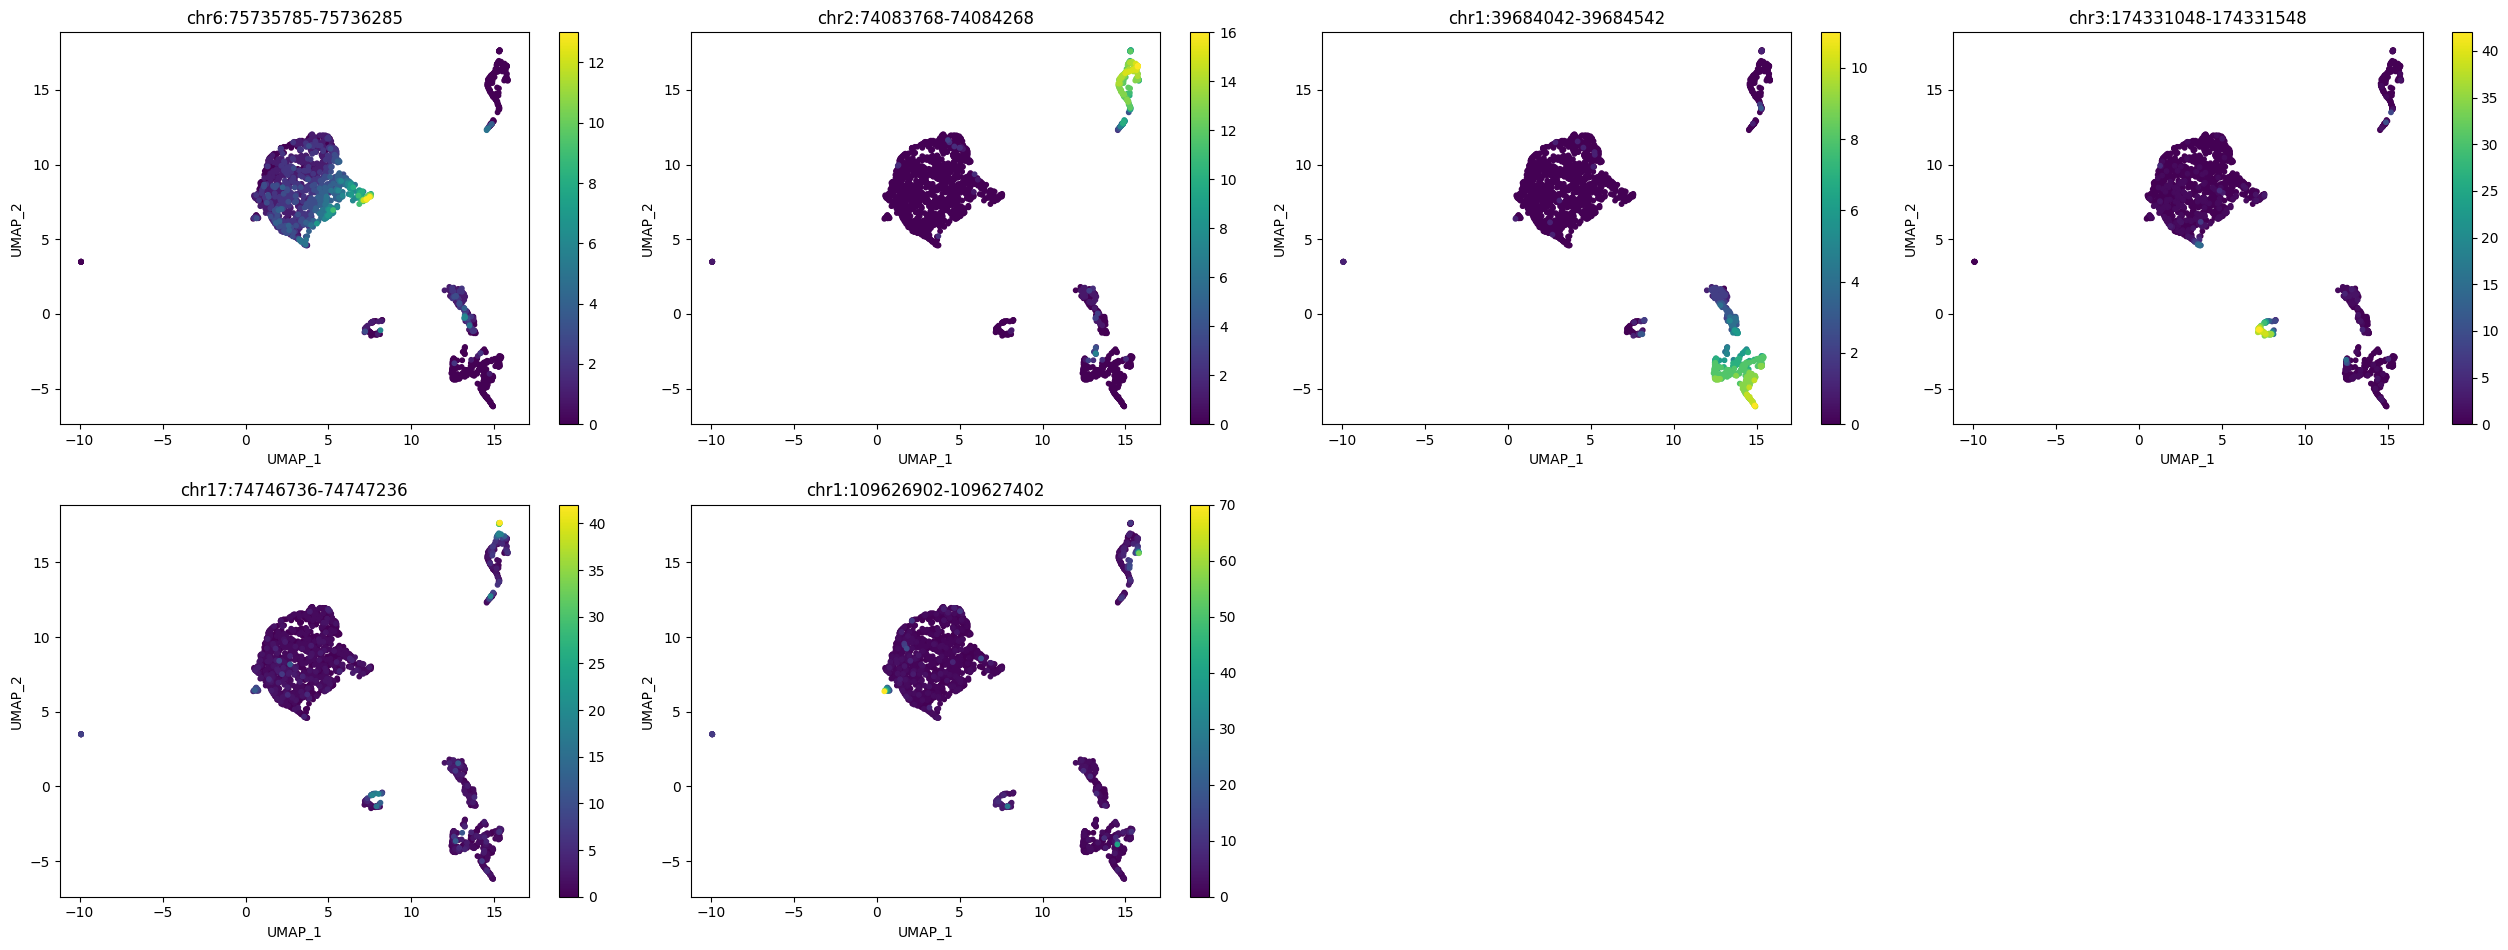

In [65]:
plot_imputed_features(
    cistopic_obj,
    reduction_name='UMAP',
    imputed_data=imputed_acc_obj,
    features=[markers_dict[x].index.tolist()[0] for x in [ 'Pro-B_cells_Q3', 'Tcm_Naive_helper_T_cells', 'Tem_Trm_cytotoxic_T_cells',
                                                         'Classical_monocytes','Mid_erythroid','Memory_B_cells']],
    scale=False,
    num_columns=4
)

In [66]:
print("Number of DARs found:")
print("---------------------")
for x in markers_dict:
    print(f"  {x}: {len(markers_dict[x])}")

Number of DARs found:
---------------------
  Classical_monocytes: 7973
  Memory_B_cells: 3889
  Mid_erythroid: 9952
  Naive_B_cells: 4412
  Pro-B_cells_Q3: 14871
  Tcm_Naive_helper_T_cells: 11239
  Tem_Trm_cytotoxic_T_cells: 10294


In [67]:
# save region sets
os.makedirs(os.path.join(out_dir, "region_sets"), exist_ok = True)
os.makedirs(os.path.join(out_dir, "region_sets", "Topics_otsu"), exist_ok = True)
os.makedirs(os.path.join(out_dir, "region_sets", "Topics_top_3k"), exist_ok = True)
os.makedirs(os.path.join(out_dir, "region_sets", "DARs_cell_type"), exist_ok = True)

In [68]:
from pycisTopic.utils import region_names_to_coordinates

In [69]:
for topic in region_bin_topics_otsu:
    region_names_to_coordinates(
        region_bin_topics_otsu[topic].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join(out_dir, "region_sets", "Topics_otsu", f"{topic}.bed"),
        sep = "\t",
        header = False, index = False
    )

In [70]:
for topic in region_bin_topics_top_3k:
    region_names_to_coordinates(
        region_bin_topics_top_3k[topic].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join(out_dir, "region_sets", "Topics_top_3k", f"{topic}.bed"),
        sep = "\t",
        header = False, index = False
    )

In [71]:
for cell_type in markers_dict:
    region_names_to_coordinates(
        markers_dict[cell_type].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join(out_dir, "region_sets", "DARs_cell_type", f"{cell_type}.bed"),
        sep = "\t",
        header = False, index = False
    )

# Gene activity

In [72]:
import pyranges as pr
from pycisTopic.gene_activity import get_gene_activity

In [73]:
chromsizes = pd.read_table(os.path.join(out_dir, "qc", "hg38.chrom_sizes_and_alias.tsv"))
chromsizes

,# ucsc,length,ensembl,refseq_id,genbank_id
0,chr1,248956422,1,NC_000001.11,CM000663.2
1,chr2,242193529,2,NC_000002.12,CM000664.2
2,chr3,198295559,3,NC_000003.12,CM000665.2
3,chr4,190214555,4,NC_000004.12,CM000666.2
4,chr5,181538259,5,NC_000005.10,CM000667.2
...,...,...,...,...,...
449,chrUn_KI270539v1,993,HSCHRUN_RANDOM_146,NT_187442.1,KI270539.1
450,chrUn_KI270385v1,990,HSCHRUN_RANDOM_195,NT_187487.1,KI270385.1
451,chrUn_KI270423v1,981,HSCHRUN_RANDOM_121,NT_187417.1,KI270423.1
452,chrUn_KI270392v1,971,HSCHRUN_RANDOM_193,NT_187485.1,KI270392.1


In [74]:
chromsizes.rename({"# ucsc": "Chromosome", "length": "End"}, axis = 1, inplace = True)
chromsizes["Start"] = 0
chromsizes = pr.PyRanges(chromsizes[["Chromosome", "Start", "End"]])

In [75]:
pr_annotation = pd.read_table(
        os.path.join(out_dir, "qc", "tss.bed")
    ).rename(
        {"Name": "Gene", "# Chromosome": "Chromosome"}, axis = 1)
pr_annotation["Transcription_Start_Site"] = pr_annotation["Start"]
pr_annotation = pr.PyRanges(pr_annotation)
pr_annotation

,Chromosome,Start,End,Gene,Score,Strand,Transcript_type,Transcription_Start_Site
0,GL000009.2,58375,58376,NaN,.,-,protein_coding,58375
1,GL000194.1,115017,115018,NaN,.,-,protein_coding,115017
2,GL000194.1,115054,115055,MAFIP,.,-,protein_coding,115054
3,GL000195.1,49163,49164,NaN,.,-,protein_coding,49163
4,GL000213.1,139654,139655,NaN,.,-,protein_coding,139654
...,...,...,...,...,...,...,...,...
87556,chrY,6911751,6911752,AMELY,.,-,protein_coding,6911751
87557,chrY,6872607,6872608,AMELY,.,-,protein_coding,6872607
87558,chrY,21918031,21918032,RBMY1E,.,-,protein_coding,21918031
87559,chrY,24047968,24047969,CDY1B,.,-,protein_coding,24047968


In [76]:
gene_act, weigths = get_gene_activity(
    imputed_acc_obj,
    pr_annotation,
    chromsizes,
    use_gene_boundaries=True, # Whether to use the whole search space or stop when encountering another gene
    upstream=[1000, 100000], # Search space upstream. The minimum means that even if there is a gene right next to it
                             # these bp will be taken (1kbp here)
    downstream=[1000,100000], # Search space downstream
    distance_weight=True, # Whether to add a distance weight (an exponential function, the weight will decrease with distance)
    decay_rate=1, # Exponent for the distance exponential funciton (the higher the faster will be the decrease)
    extend_gene_body_upstream=10000, # Number of bp upstream immune to the distance weight (their value will be maximum for
                          #this weight)
    extend_gene_body_downstream=500, # Number of bp downstream immune to the distance weight
    gene_size_weight=False, # Whether to add a weights based on the length of the gene
    gene_size_scale_factor='median', # Dividend to calculate the gene size weigth. Default is the median value of all genes
                          #in the genome
    remove_promoters=False, # Whether to remove promoters when computing gene activity scores
    average_scores=True, # Whether to divide by the total number of region assigned to a gene when calculating the gene
                          #activity score
    scale_factor=1, # Value to multiply for the final gene activity matrix
    extend_tss=[10,10], # Space to consider a promoter
    gini_weight = True, # Whether to add a gini index weigth. The more unique the region is, the higher this weight will be
    return_weights= True, # Whether to return the final weights
    project='Gene_activity') # Project name for the gene activity object

2025-07-11 14:10:37,468 cisTopic     INFO     Calculating gene boundaries
2025-07-11 14:10:53,892 cisTopic     INFO     Calculating distances


join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.


2025-07-11 14:11:02,726 cisTopic     INFO     Calculating distance weigths
2025-07-11 14:11:03,252 cisTopic     INFO     Distance weights done
2025-07-11 14:11:03,253 cisTopic     INFO     Calculating gini weights
2025-07-11 14:11:08,808 cisTopic     INFO     Getting gene activity scores
2025-07-11 14:13:21,703 cisTopic     INFO     Creating imputed features object


In [ ]:
DAG_markers_dict= find_diff_features(
    cistopic_obj,
    gene_act,
    variable='cell_type_all',
    var_features=None,
    contrasts=None,
    adjpval_thr=0.05,
    log2fc_thr=np.log2(1.5),
    n_cpu=5,
    _temp_dir='/ray_spill',
    split_pattern = '-')

2025-07-11 14:13:25,435	INFO worker.py:1724 -- Started a local Ray instance.


2025-07-11 14:13:26,484 cisTopic     INFO     Subsetting data for Classical_monocytes (82 of 2108)
2025-07-11 14:13:29,242 cisTopic     INFO     Computing p-value for Classical_monocytes
2025-07-11 14:13:33,158 cisTopic     INFO     Computing log2FC for Classical_monocytes
2025-07-11 14:13:35,183 cisTopic     INFO     Classical_monocytes done!
2025-07-11 14:13:35,186 cisTopic     INFO     Subsetting data for Memory_B_cells (17 of 2108)
2025-07-11 14:13:35,263 cisTopic     INFO     Computing p-value for Memory_B_cells
2025-07-11 14:13:38,111 cisTopic     INFO     Computing log2FC for Memory_B_cells
2025-07-11 14:13:38,144 cisTopic     INFO     Memory_B_cells done!
2025-07-11 14:13:38,146 cisTopic     INFO     Subsetting data for Mid_erythroid (18 of 2108)
2025-07-11 14:13:38,228 cisTopic     INFO     Computing p-value for Mid_erythroid
2025-07-11 14:13:41,131 cisTopic     INFO     Computing log2FC for Mid_erythroid
2025-07-11 14:13:41,164 cisTopic     INFO     Mid_erythroid done!
2025-0

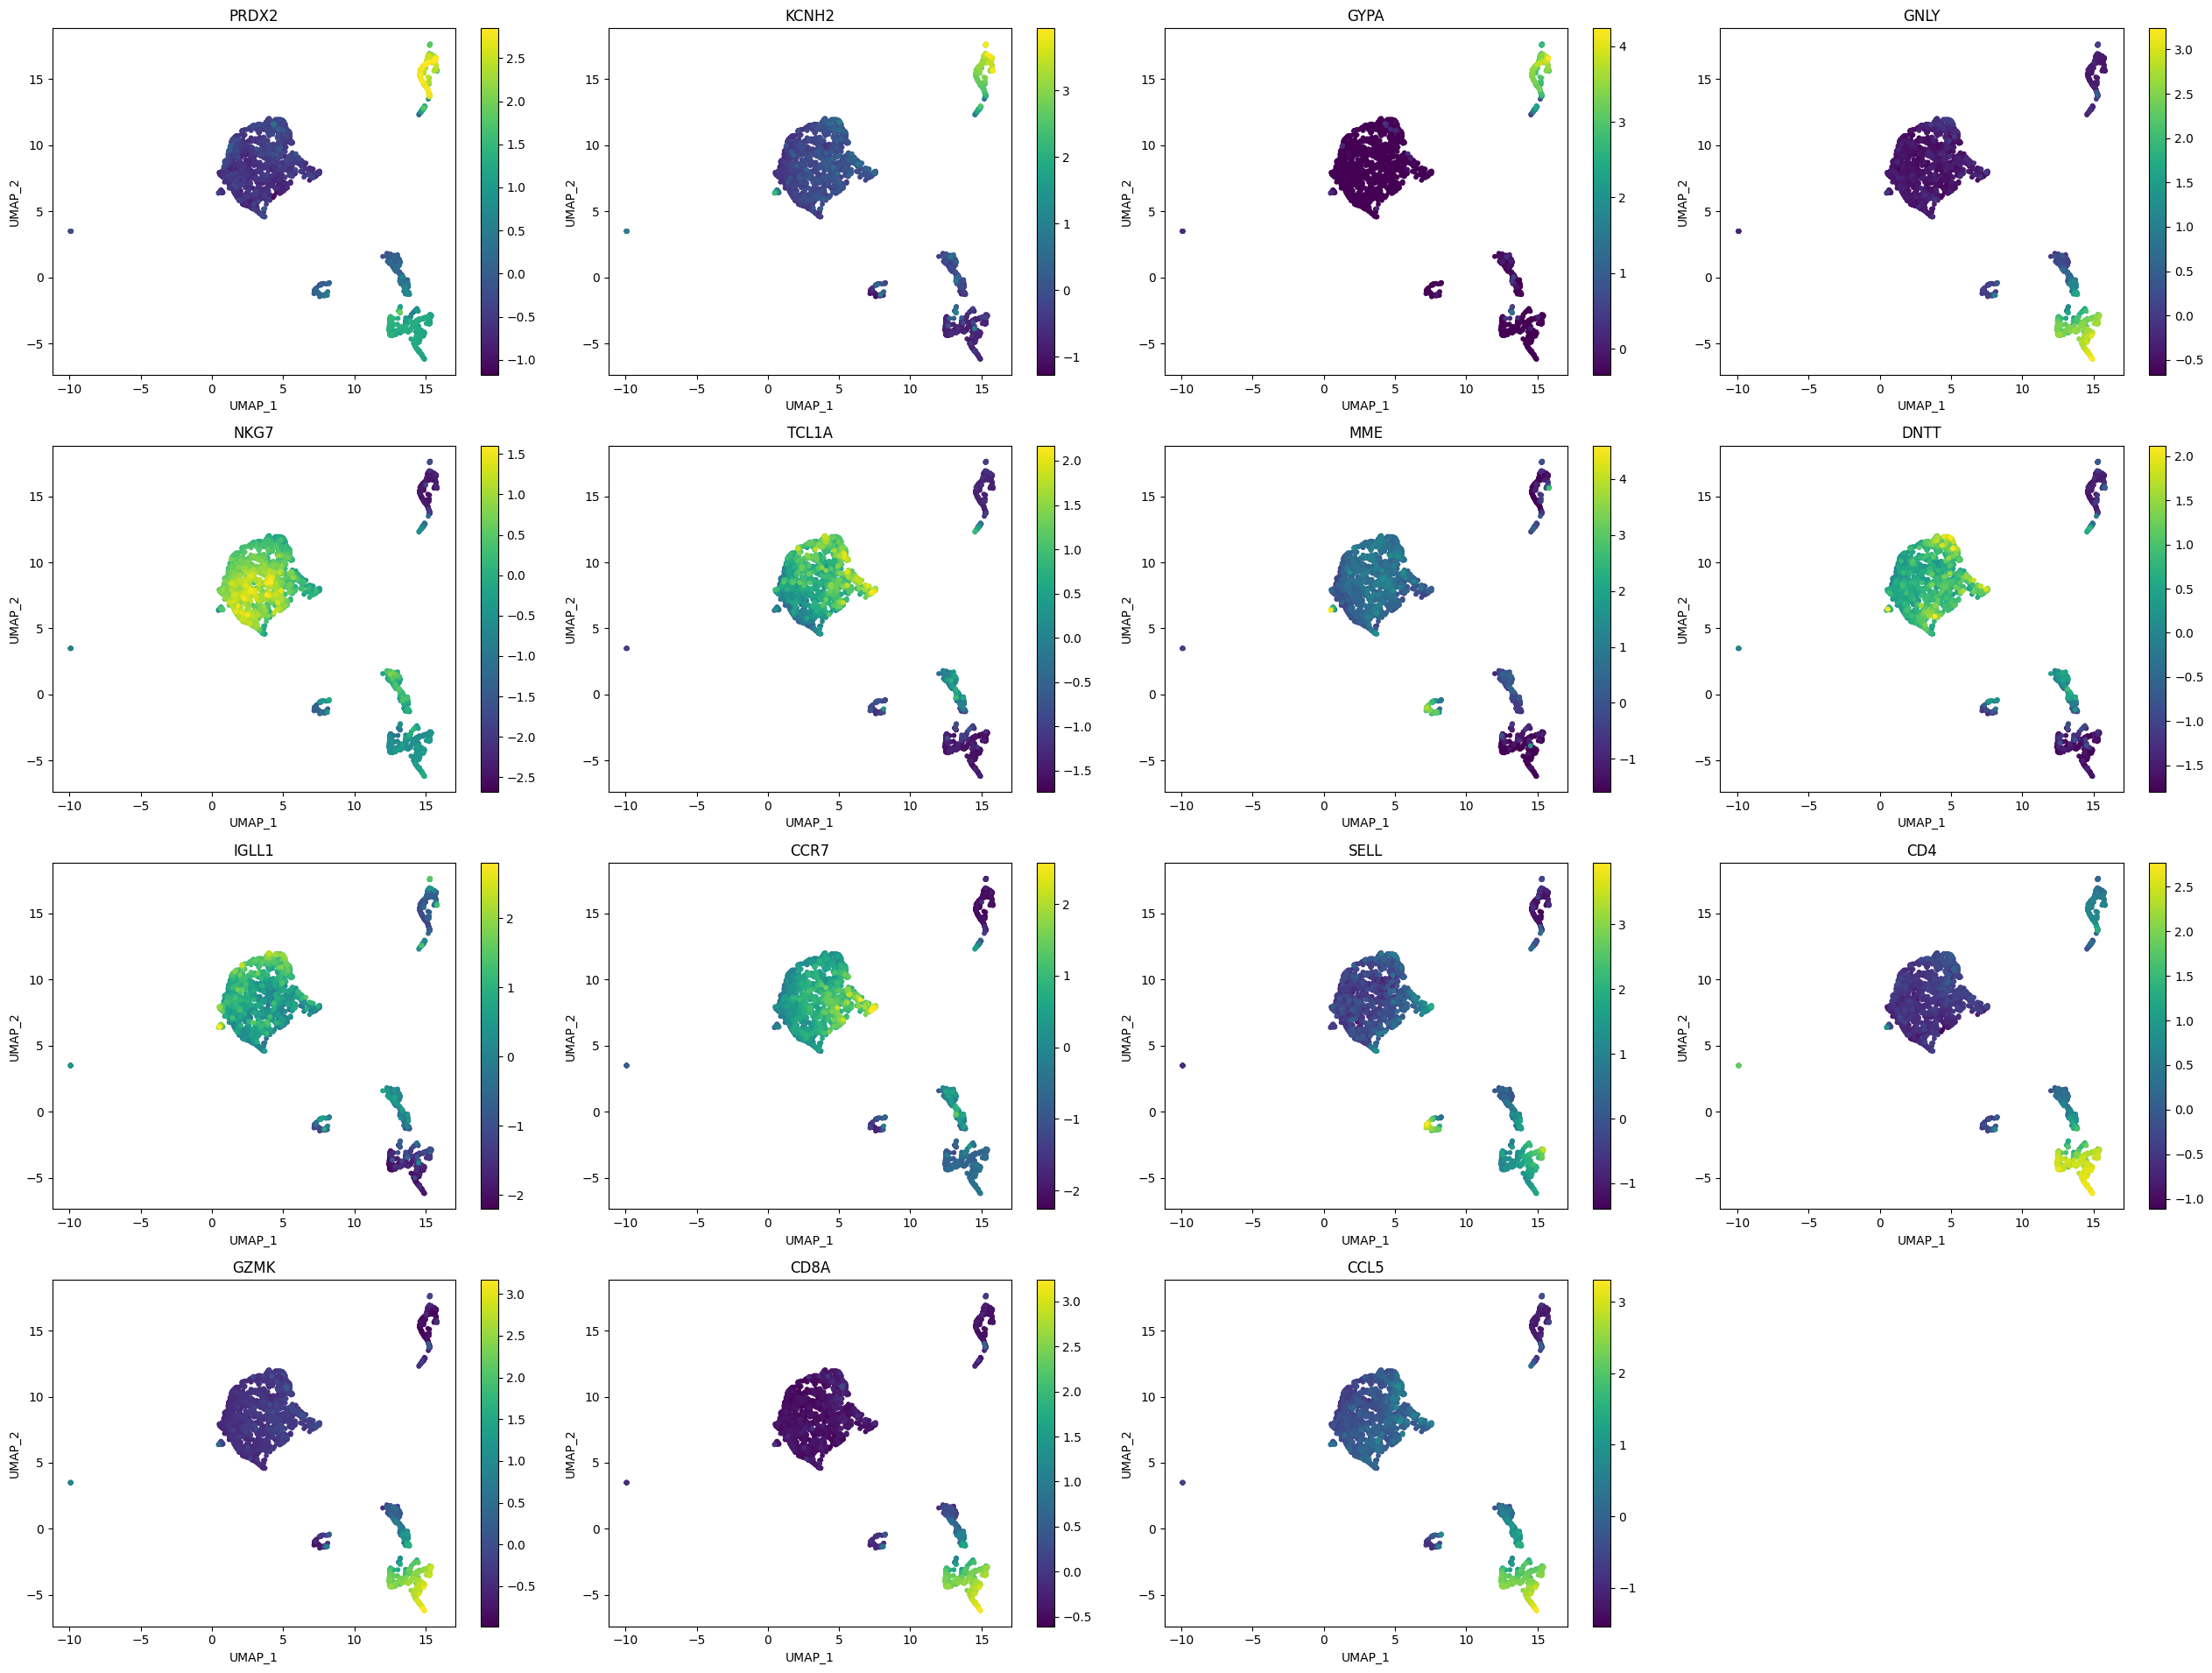

In [78]:
# cell typist
plot_imputed_features(
    cistopic_obj,
    reduction_name='UMAP',
    imputed_data=gene_act,
    features=[
        'PRDX2','KCNH2','GYPA', # Mid erythroid
        'GNLY','NKG7', # CD16+ NK cells
        'TCL1A', # naive B cells
        'MME','DNTT','IGLL1', # Pro-B cells
        'CCR7','SELL','CD4', # Tcm/Naive helper T cells
        'GZMK','CD8A','CCL5'], # Tem/Trm cytotoxic T cells
    scale=True,
    num_columns=4
)


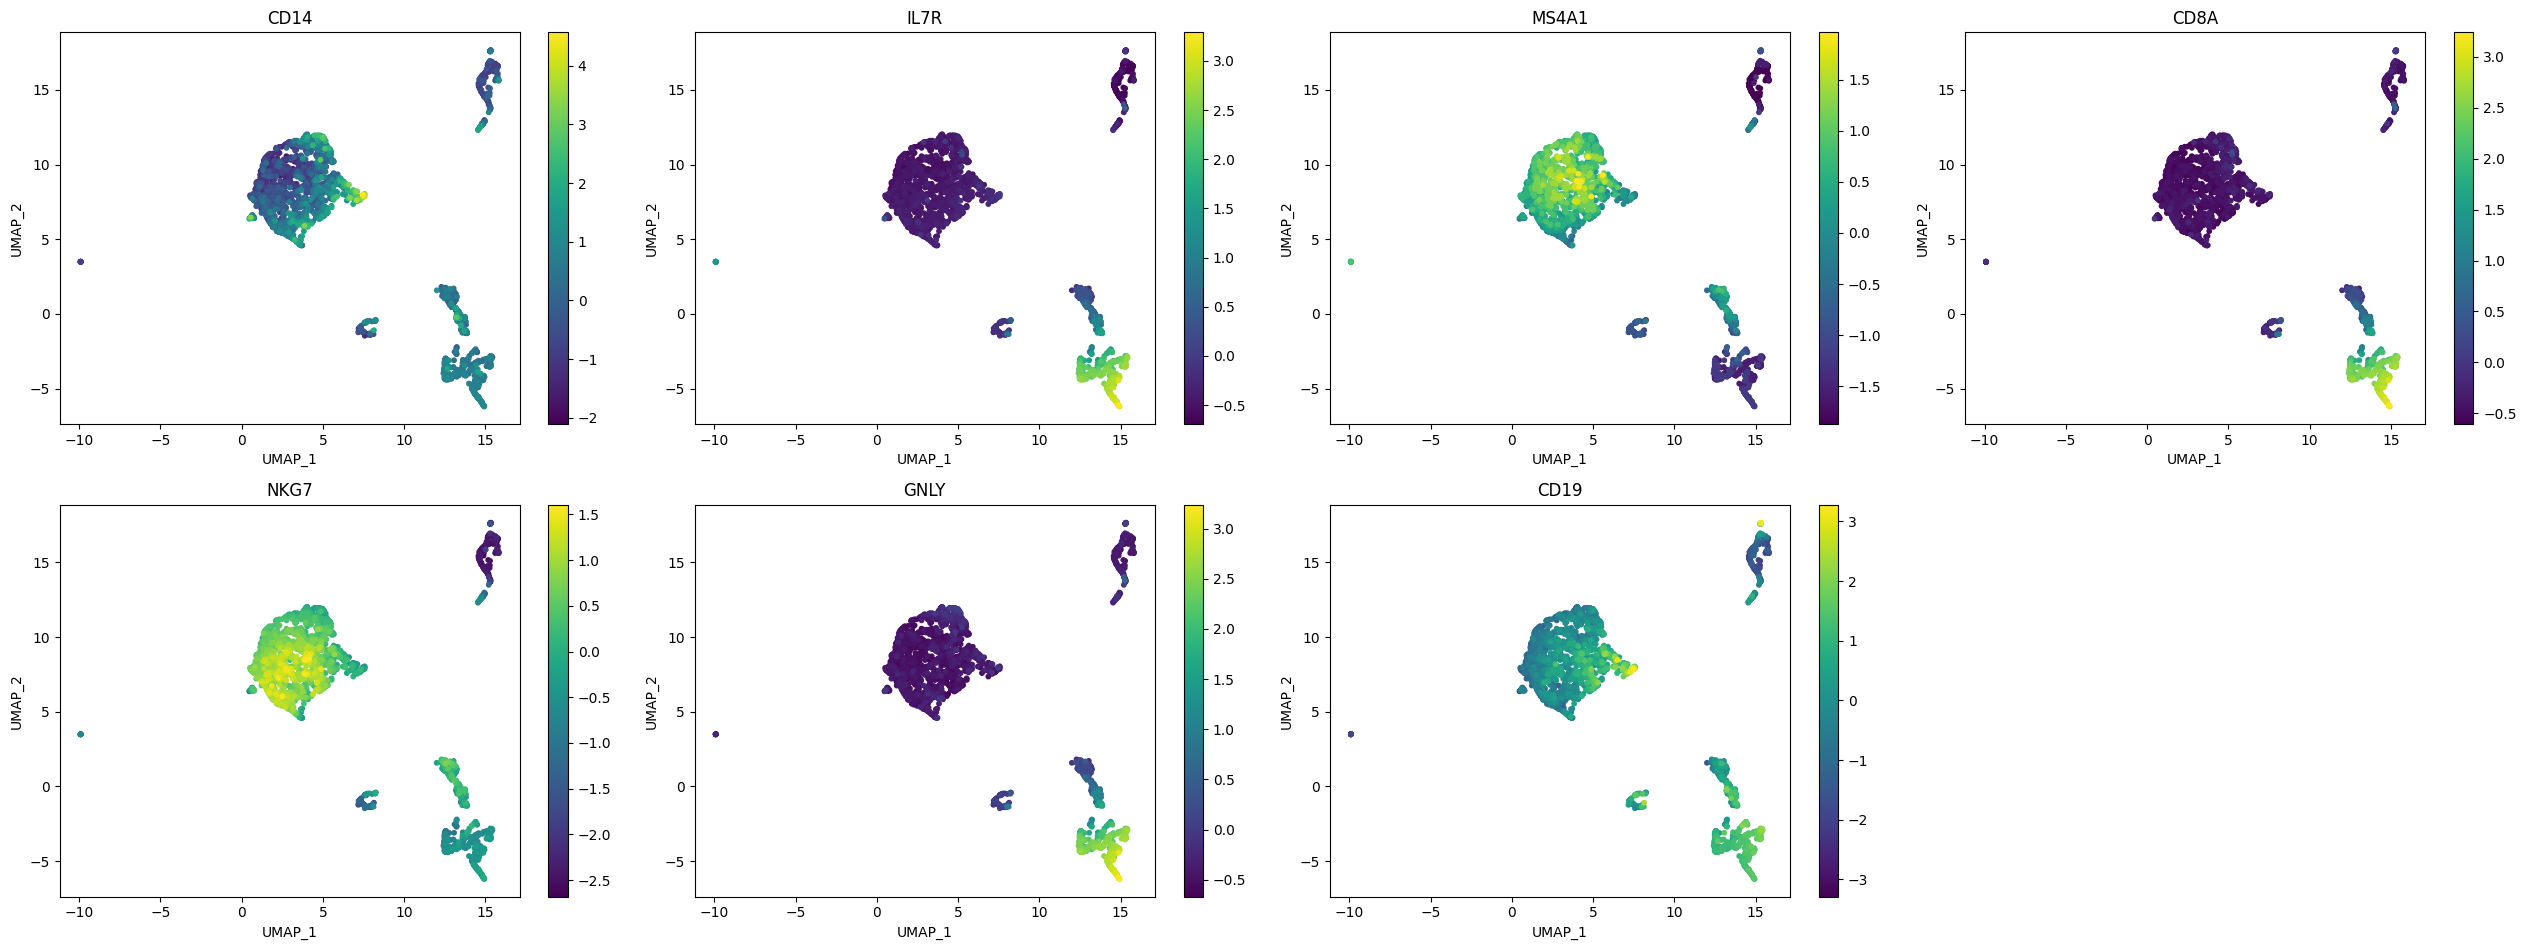

In [79]:
plot_imputed_features(
    cistopic_obj,
    reduction_name='UMAP',
    imputed_data=gene_act,
    features=['CD14', # CD14 mono
              'IL7R', # CD4
              'MS4A1', # B
              'CD8A',  #CD8+T
              'NKG7','GNLY', #NK
              'CD19'], #CD19 B-all
    scale=True,
    num_columns=4
)

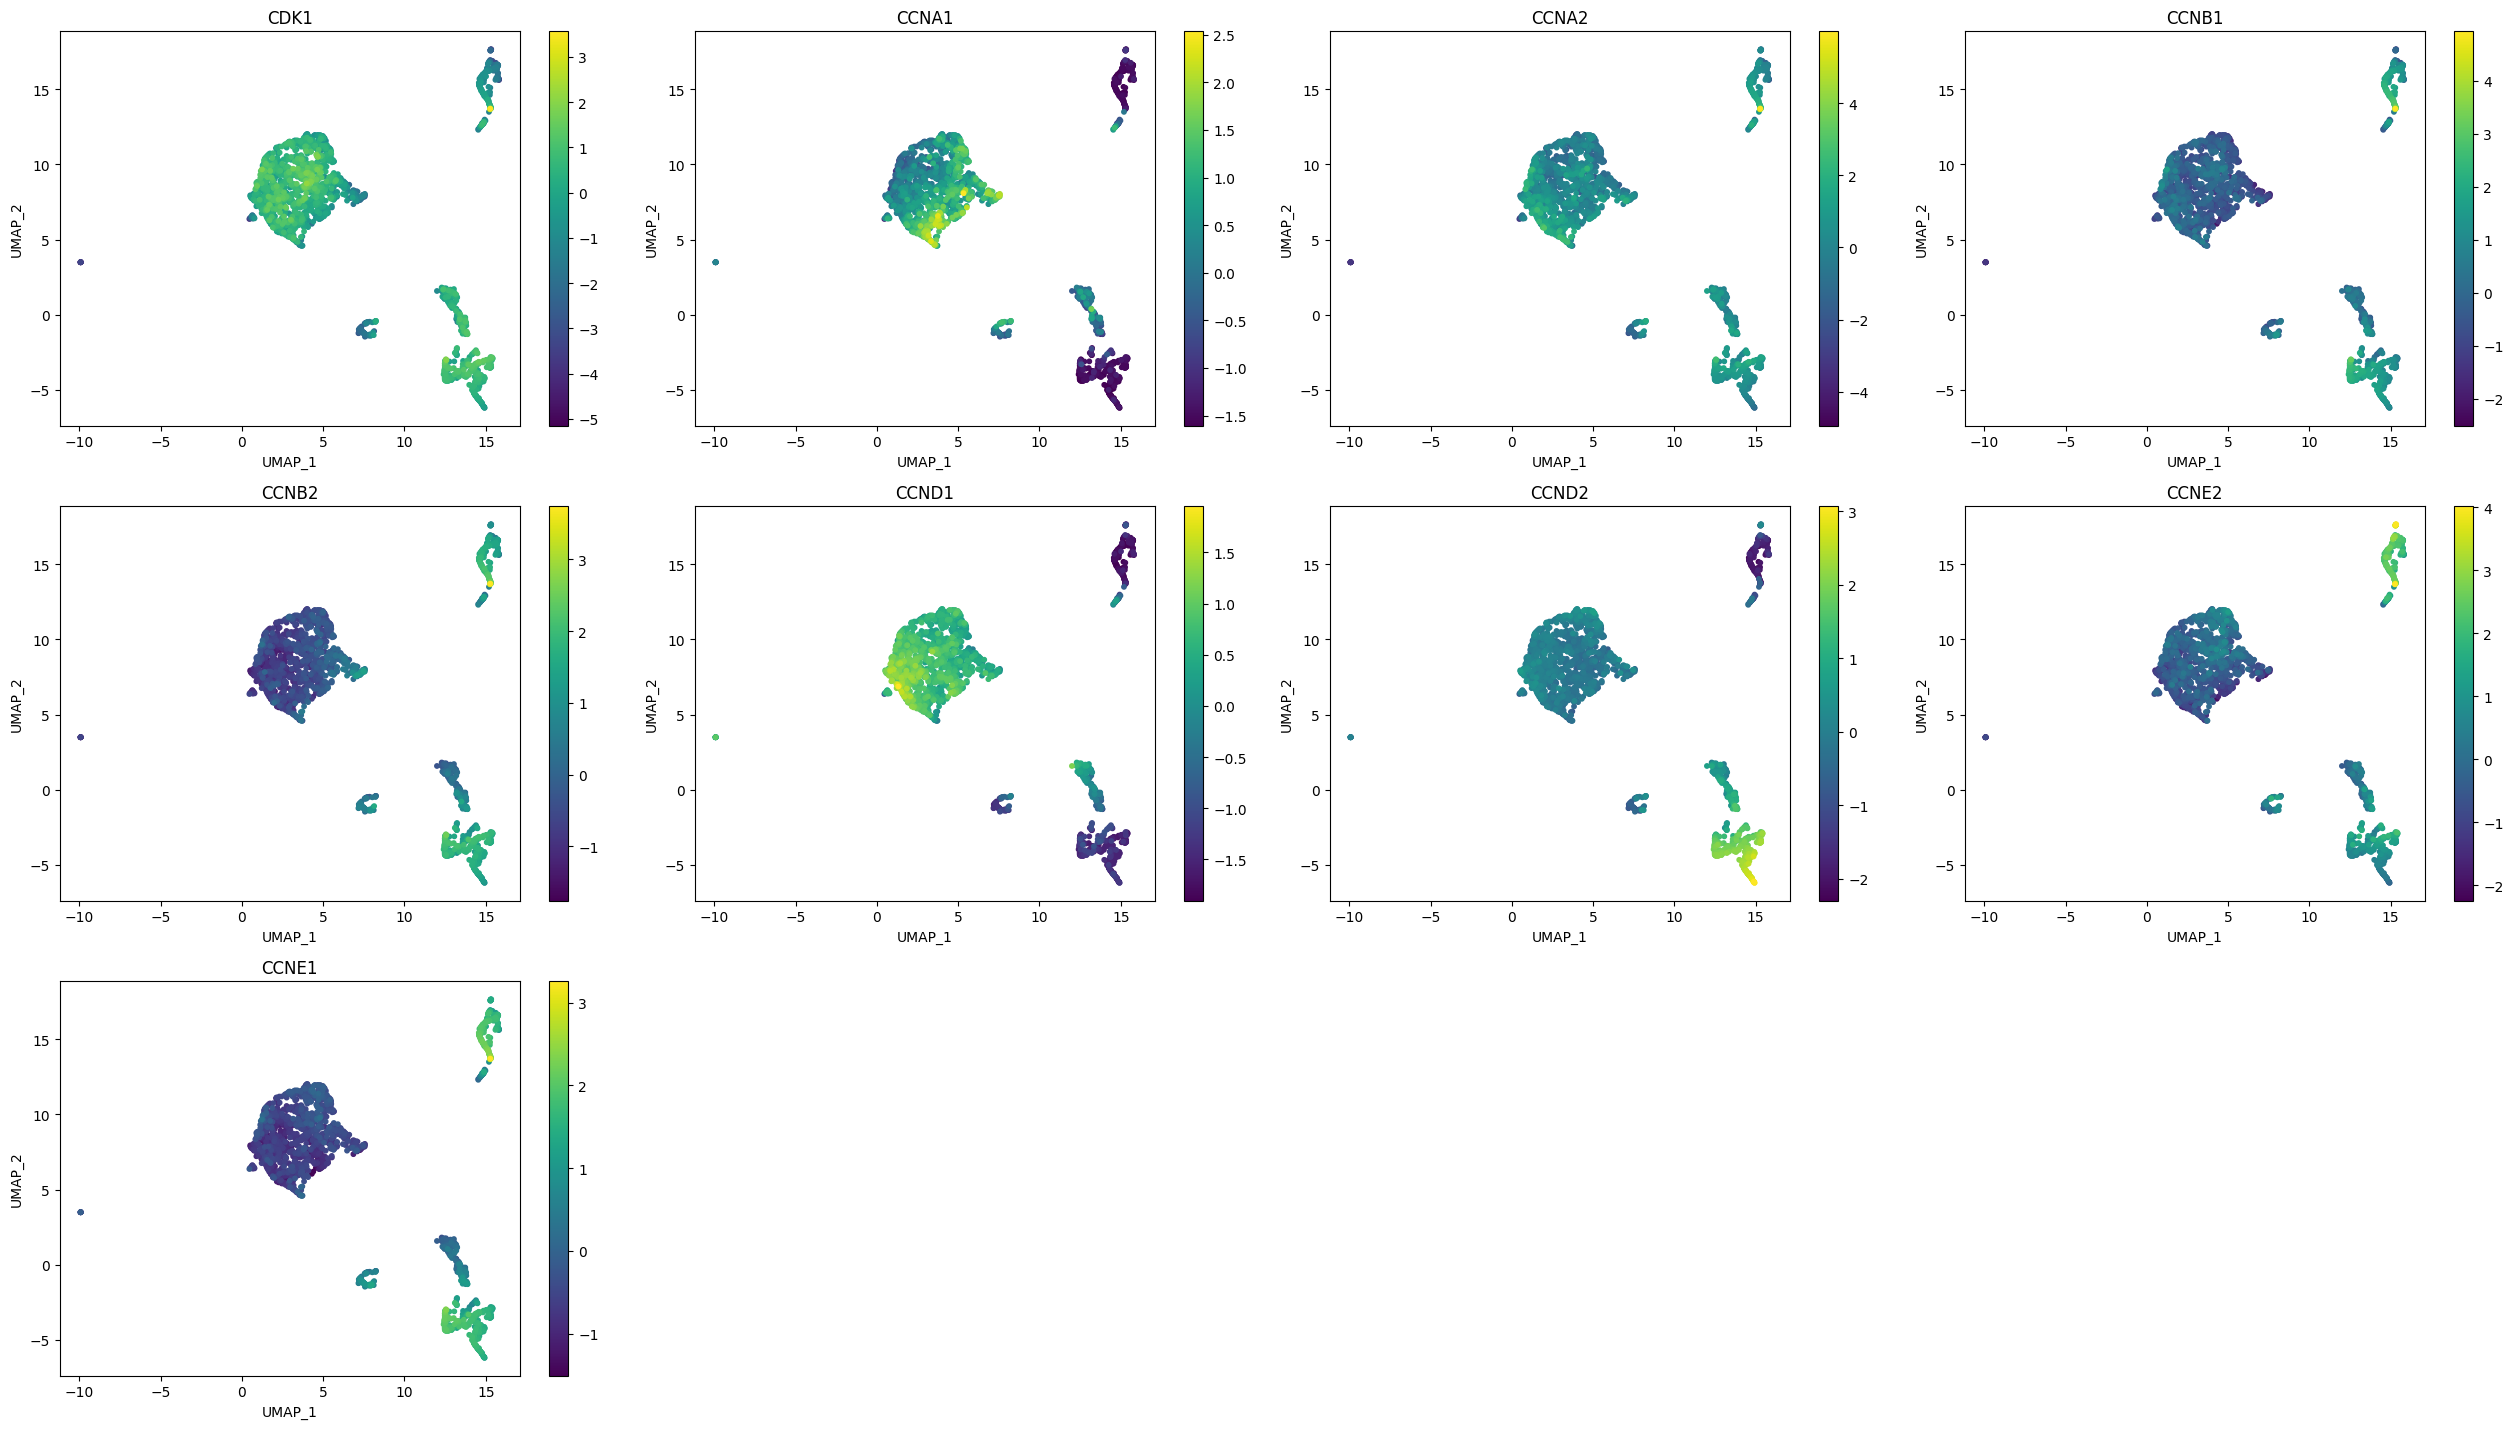

In [80]:
# cell cycle
plot_imputed_features(
    cistopic_obj,
    reduction_name='UMAP',
    imputed_data=gene_act,
    features=['CDK1',
              'CCNA1','CCNA2',
              'CCNB1','CCNB2',
              'CCND1','CCND2',
              'CCNE2','CCNE1'],
    scale=True,
    num_columns=4
)

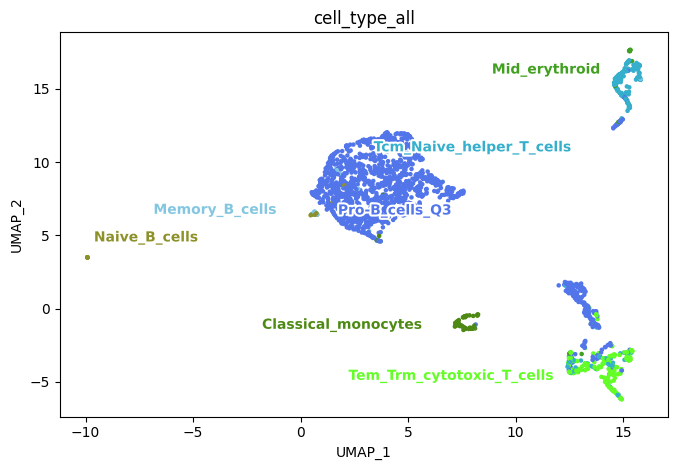

In [81]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['cell_type_all'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

In [82]:
print("Number of DAGs found:")
print("---------------------")
for x in markers_dict:
    print(f"  {x}: {len(DAG_markers_dict[x])}")

Number of DAGs found:
---------------------
  Classical_monocytes: 2260
  Memory_B_cells: 1815
  Mid_erythroid: 2979
  Naive_B_cells: 2099
  Pro-B_cells_Q3: 3323
  Tcm_Naive_helper_T_cells: 4611
  Tem_Trm_cytotoxic_T_cells: 4410


In [83]:
pickle.dump(
    cistopic_obj,
    open(os.path.join(out_dir, "cistopic_obj.pkl"), "wb")
)

## Save object to anndata 

In [ ]:
import scanpy as sc
ad = sc.AnnData(
    X = cistopic_obj.binary_matrix.T,
    obs = cistopic_obj.cell_data,
    var = cistopic_obj.region_data,
    obsm = {
	embedding: cistopic_obj.projections["cell"][embedding].values
        for embedding in cistopic_obj.projections["cell"].keys()}
)

In [85]:
ad

AnnData object with n_obs × n_vars = 2108 × 179331
    obs: 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'barcode_rank', 'total_fragments_count', 'log10_total_fragments_count', 'unique_fragments_count', 'log10_unique_fragments_count', 'total_fragments_in_peaks_count', 'log10_total_fragments_in_peaks_count', 'unique_fragments_in_peaks_count', 'log10_unique_fragments_in_peaks_count', 'fraction_of_fragments_in_peaks', 'duplication_count', 'duplication_ratio', 'tss_enrichment', 'pdf_values_for_tss_enrichment', 'pdf_values_for_fraction_of_fragments_in_peaks', 'pdf_values_for_duplication_ratio', 'barcode', 'doublets_atac', 'doublet_outlier', 'cell_type', 'sample', 'pycisTopic_leiden_10_0.2', 'pycisTopic_leiden_10_0.3', 'pycisTopic_leiden_10_0.6', 'pycisTopic_leiden_10_1.2', 'pycisTopic_leiden_10_3', 'pycisTopic_leiden_10_6', 'is_nan', 'cell_type_all'
    var: 'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag

In [86]:
ad.obsm = {key.lower(): value for key, value in ad.obsm.items()} # put obsm keys to lower to be functional in scanpy

In [87]:
ad

AnnData object with n_obs × n_vars = 2108 × 179331
    obs: 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'barcode_rank', 'total_fragments_count', 'log10_total_fragments_count', 'unique_fragments_count', 'log10_unique_fragments_count', 'total_fragments_in_peaks_count', 'log10_total_fragments_in_peaks_count', 'unique_fragments_in_peaks_count', 'log10_unique_fragments_in_peaks_count', 'fraction_of_fragments_in_peaks', 'duplication_count', 'duplication_ratio', 'tss_enrichment', 'pdf_values_for_tss_enrichment', 'pdf_values_for_fraction_of_fragments_in_peaks', 'pdf_values_for_duplication_ratio', 'barcode', 'doublets_atac', 'doublet_outlier', 'cell_type', 'sample', 'pycisTopic_leiden_10_0.2', 'pycisTopic_leiden_10_0.3', 'pycisTopic_leiden_10_0.6', 'pycisTopic_leiden_10_1.2', 'pycisTopic_leiden_10_3', 'pycisTopic_leiden_10_6', 'is_nan', 'cell_type_all'
    var: 'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag

... storing 'sample_id' as categorical
... storing 'cell_type' as categorical
... storing 'pycisTopic_leiden_10_0.2' as categorical
... storing 'pycisTopic_leiden_10_0.3' as categorical
... storing 'pycisTopic_leiden_10_0.6' as categorical
... storing 'pycisTopic_leiden_10_1.2' as categorical
... storing 'pycisTopic_leiden_10_3' as categorical
... storing 'pycisTopic_leiden_10_6' as categorical
... storing 'cell_type_all' as categorical
... storing 'Chromosome' as categorical
/opt/venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


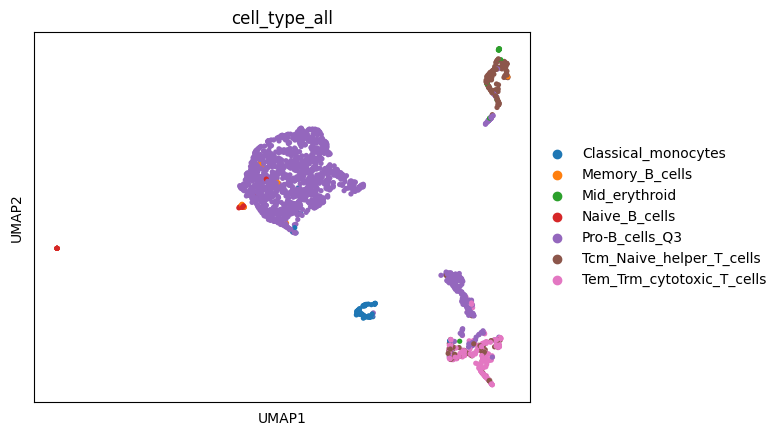

In [88]:
sc.pl.umap(ad, color ="cell_type_all")

In [89]:
ad.obs

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,barcode_rank,total_fragments_count,log10_total_fragments_count,unique_fragments_count,log10_unique_fragments_count,...,cell_type,sample,pycisTopic_leiden_10_0.2,pycisTopic_leiden_10_0.3,pycisTopic_leiden_10_0.6,pycisTopic_leiden_10_1.2,pycisTopic_leiden_10_3,pycisTopic_leiden_10_6,is_nan,cell_type_all
ACGCAAGCAGGAATCG-1-Q3___Q3,20049,4.302093,14510,4.161667,Q3,190,55419,4.743667,30767,4.488099,...,Tem_Trm_cytotoxic_T_cells,Q3,4,3,5,13,11,15,False,Tem_Trm_cytotoxic_T_cells
AACTACTCAAGTCGCT-1-Q3___Q3,6785,3.83155,5660,3.752816,Q3,692,18389,4.264582,10676,4.028449,...,Tcm_Naive_helper_T_cells,Q3,3,4,6,9,1,39,False,Tcm_Naive_helper_T_cells
AGCCAGTGTCATAACG-1-Q3___Q3,9067,3.957464,7922,3.898835,Q3,403,29614,4.471512,16228,4.210292,...,Classical_monocytes,Q3,5,5,9,14,8,55,False,Classical_monocytes
AGACAATAGTAACCAC-1-Q3___Q3,2602,3.415307,2403,3.380754,Q3,1455,7644,3.883377,4261,3.629613,...,Pro-B_cells_Q3,Q3,3,3,10,17,28,20,False,Pro-B_cells_Q3
CGATGTCCACGTAATT-1-Q3___Q3,13796,4.139753,11665,4.066885,Q3,215,48331,4.684235,27219,4.434888,...,Pro-B_cells_Q3,Q3,0,0,3,3,4,4,False,Pro-B_cells_Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TATAGCTCATTGCGAC-1-Q3___Q3,1931,3.285782,1811,3.257918,Q3,1936,4791,3.680517,2560,3.408410,...,Pro-B_cells_Q3,Q3,0,0,2,6,10,5,False,Pro-B_cells_Q3
AAACGCGCAACAACAA-1-Q3___Q3,1081,3.033826,1001,3.000434,Q3,2324,2622,3.418798,1519,3.181844,...,Classical_monocytes,Q3,5,5,9,14,8,50,False,Classical_monocytes
CGAGGAAGTGTGAGAG-1-Q3___Q3,1476,3.169086,1377,3.138934,Q3,2156,3512,3.545678,1936,3.287130,...,Tem_Trm_cytotoxic_T_cells,Q3,2,2,1,10,26,32,False,Tem_Trm_cytotoxic_T_cells
AGCCGGTTCGTTACTT-1-Q3___Q3,1291,3.110926,1259,3.100026,Q3,2085,3874,3.588272,2121,3.326745,...,Pro-B_cells_Q3,Q3,0,0,2,1,15,33,False,Pro-B_cells_Q3


In [101]:
ad.obs = ad.obs.drop('barcode',axis=1)

In [102]:
ad.obs = ad.obs.apply(lambda col: col.astype(float) if col.dtype == 'object' else col)

In [103]:
ad.obs

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,barcode_rank,total_fragments_count,log10_total_fragments_count,unique_fragments_count,log10_unique_fragments_count,...,cell_type,sample,pycisTopic_leiden_10_0.2,pycisTopic_leiden_10_0.3,pycisTopic_leiden_10_0.6,pycisTopic_leiden_10_1.2,pycisTopic_leiden_10_3,pycisTopic_leiden_10_6,is_nan,cell_type_all
ACGCAAGCAGGAATCG-1-Q3___Q3,20049.0,4.302093,14510.0,4.161667,Q3,190,55419,4.743667,30767,4.488099,...,Tem_Trm_cytotoxic_T_cells,Q3,4,3,5,13,11,15,False,Tem_Trm_cytotoxic_T_cells
AACTACTCAAGTCGCT-1-Q3___Q3,6785.0,3.831550,5660.0,3.752816,Q3,692,18389,4.264582,10676,4.028449,...,Tcm_Naive_helper_T_cells,Q3,3,4,6,9,1,39,False,Tcm_Naive_helper_T_cells
AGCCAGTGTCATAACG-1-Q3___Q3,9067.0,3.957464,7922.0,3.898835,Q3,403,29614,4.471512,16228,4.210292,...,Classical_monocytes,Q3,5,5,9,14,8,55,False,Classical_monocytes
AGACAATAGTAACCAC-1-Q3___Q3,2602.0,3.415307,2403.0,3.380754,Q3,1455,7644,3.883377,4261,3.629613,...,Pro-B_cells_Q3,Q3,3,3,10,17,28,20,False,Pro-B_cells_Q3
CGATGTCCACGTAATT-1-Q3___Q3,13796.0,4.139753,11665.0,4.066885,Q3,215,48331,4.684235,27219,4.434888,...,Pro-B_cells_Q3,Q3,0,0,3,3,4,4,False,Pro-B_cells_Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TATAGCTCATTGCGAC-1-Q3___Q3,1931.0,3.285782,1811.0,3.257918,Q3,1936,4791,3.680517,2560,3.408410,...,Pro-B_cells_Q3,Q3,0,0,2,6,10,5,False,Pro-B_cells_Q3
AAACGCGCAACAACAA-1-Q3___Q3,1081.0,3.033826,1001.0,3.000434,Q3,2324,2622,3.418798,1519,3.181844,...,Classical_monocytes,Q3,5,5,9,14,8,50,False,Classical_monocytes
CGAGGAAGTGTGAGAG-1-Q3___Q3,1476.0,3.169086,1377.0,3.138934,Q3,2156,3512,3.545678,1936,3.287130,...,Tem_Trm_cytotoxic_T_cells,Q3,2,2,1,10,26,32,False,Tem_Trm_cytotoxic_T_cells
AGCCGGTTCGTTACTT-1-Q3___Q3,1291.0,3.110926,1259.0,3.100026,Q3,2085,3874,3.588272,2121,3.326745,...,Pro-B_cells_Q3,Q3,0,0,2,1,15,33,False,Pro-B_cells_Q3


In [104]:
import datetime
date = datetime.datetime.now().strftime('%Y%m%d')
ad.write(f'./outs/{date}_atac_ball_processed.h5ad')

In [105]:
pip list

Package                              Version
------------------------------------ -----------------
adjustText                           1.0.4
aiohttp                              3.9.3
aiosignal                            1.3.1
anndata                              0.10.5.post1
annoy                                1.17.3
appdirs                              1.4.4
arboreto                             0.1.6
argparse-dataclass                   2.0.0
array_api_compat                     1.5.1
asttokens                            2.4.1
attr                                 0.3.2
attrs                                23.2.0
bbknn                                1.6.0
beautifulsoup4                       4.12.3
bidict                               0.23.1
bioservices                          1.11.2
blosc2                               2.5.1
bokeh                                3.4.0
boltons                              23.1.1
bs4                                  0.0.2
cattrs                     